## b3 projected varj alpha=0.5

(a)


Fit slope = 0.475, intercept = -1.775


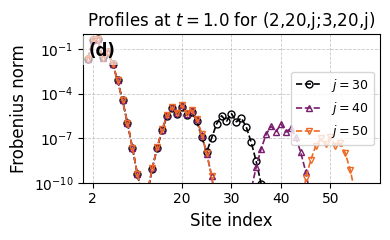

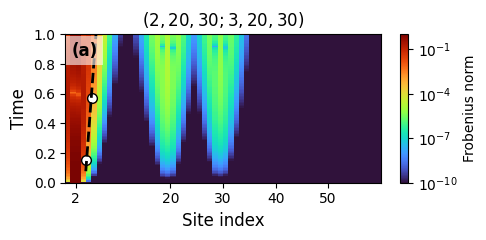

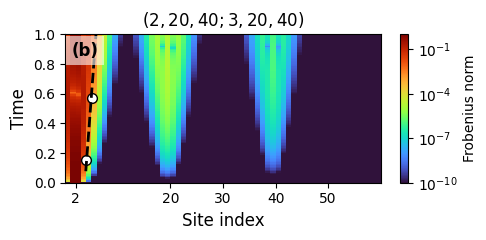

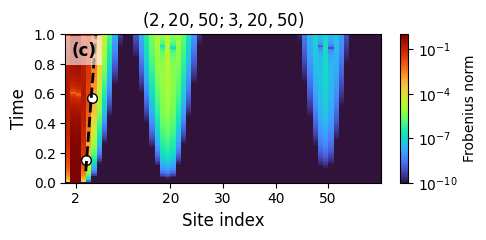

In [2]:
import numpy as np
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# Load Mathematica/C-export style text files (robust)
# -----------------------------
def load_mathematica_data(filename):
    """
    Robust loader for numeric tables exported by Mathematica or C.
    Handles:
      - commas or spaces
      - braces { }
      - "*^" scientific notation
      - drops imaginary parts like "+ 0.*I"
    Returns: 2D numpy array (rows = time steps)
    """
    data = []
    filename = Path(filename)
    if not filename.exists():
        raise FileNotFoundError(f"File not found: {filename}")

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.replace("*^", "e").strip()
            line = line.lstrip("{").rstrip("}")
            if not line:
                continue

            line = line.replace(",", " ").replace("{", " ").replace("}", " ")
            line = line.replace("+ 0.*I", "").replace("+0.*I", "")

            tokens = re.findall(r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?", line)
            if not tokens:
                continue

            row = []
            for t in tokens:
                try:
                    row.append(float(t))
                except ValueError:
                    pass
            if row:
                data.append(row)

    arr = np.array(data, dtype=float)
    if arr.ndim != 2 or arr.size == 0:
        raise ValueError(f"Parsed empty/invalid array from: {filename}")
    return arr


def maybe_time_order(frho, col0_is_time=True):
    """If first column is time and mostly decreasing, reverse rows."""
    if not col0_is_time or frho.shape[1] == 0:
        return frho
    t = frho[:, 0]
    if np.nanmean(np.diff(t) < 0) > 0.8:
        return frho[::-1, :]
    return frho


def build_rho_per_site(frho, ns, col0_is_time=True):
    """
    Reconstruct rho[t, site, 2, 2] where each site has (a,b,c) columns:
      rho = [[a, b + i c],
             [b - i c, 1 - a]]

    If col0_is_time:
      a at 1+3*site, b at 2+3*site, c at 3+3*site
    else:
      a at 0+3*site, b at 1+3*site, c at 2+3*site
    """
    offset = 1 if col0_is_time else 0
    needed_cols = offset + 3 * ns
    if frho.shape[1] < needed_cols:
        raise ValueError(
            f"Need at least {needed_cols} cols for ns={ns} (col0_is_time={col0_is_time}), "
            f"but file has {frho.shape[1]} cols."
        )

    a = np.stack([frho[:, offset + 3 * s] for s in range(ns)], axis=1)
    b = np.stack([frho[:, offset + 3 * s + 1] for s in range(ns)], axis=1)
    c = np.stack([frho[:, offset + 3 * s + 2] for s in range(ns)], axis=1)

    rho = np.zeros((frho.shape[0], ns, 2, 2), dtype=np.complex128)
    rho[:, :, 0, 0] = a
    rho[:, :, 0, 1] = b + 1j * c
    rho[:, :, 1, 0] = b - 1j * c
    rho[:, :, 1, 1] = 1.0 - a
    return rho


def frobenius_norm_delta(rhona, rhoa, scale=1 * np.sqrt(2.0)):
    """
    FrobeniusNorm[t, site] = sqrt(Tr(Δρ†Δρ)) * 100*sqrt(2)
    """
    delta = rhona - rhoa  # [t, site, 2, 2]
    dd = np.conjugate(np.transpose(delta, (0, 1, 3, 2))) @ delta  # [t, site, 2, 2]
    tr = dd[..., 0, 0] + dd[..., 1, 1]  # [t, site]
    F = np.sqrt(np.real(tr)) * scale
    return F


def time_index_for_t(frho, target_t, col0_is_time=True, tInterval=0.01):
    """
    Return the closest time index to target_t.
    If col0_is_time: uses frho[:,0] as time axis.
    Else: uses integer index * tInterval.
    """
    n_steps = frho.shape[0]
    if col0_is_time:
        t_axis = frho[:, 0]
        return int(np.argmin(np.abs(t_axis - target_t)))
    else:
        idx = int(round(target_t / tInterval))
        return max(0, min(idx, n_steps - 1))


# -----------------------------
# Settings
# -----------------------------
base_dir = Path(r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR")
os.makedirs("plt", exist_ok=True)

j_values = [30, 40, 50]   # <-- set this
ns = 100                  # <-- number of sites
tInterval = 0.01
col0_is_time = True       # set False if file has no time column

# profile time
time_for_profile = 1.0

# Overlays (optional)
arrivals = [(4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)]
x_points = np.array([a[0] for a in arrivals])
y_points = np.array([a[1] for a in arrivals])
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)
print(f"Fit slope = {fit_params[0]:.3f}, intercept = {fit_params[1]:.3f}")


# ---- Filename function: adjust THIS to match your real pattern exactly ----
def frho_paths_for(v):
    """
    Return (pathA, pathNA) for given v (your 'j').

    Your current patterns:
      b3projvaryja05OBC{v}frhoA.txt
      b3projvaryja05OBC{v}frhoNA.txt
    with a special case v==0 having OBC{ns} in the name.
    """
    if v == 0:
        locA = base_dir / f"b3projvaryja05OBC{ns}frhoA.txt"
        locNA = base_dir / f"b3projvaryja05OBC{ns}frhoNA.txt"
    else:
        locA = base_dir / f"b3projvaryja05OBC{v}frhoA.txt"
        locNA = base_dir / f"b3projvaryja05OBC{v}frhoNA.txt"
    return locA, locNA


# -----------------------------
# Profiles overlay (ONE figure for all v at t=1)
# -----------------------------
plt.figure(figsize=(4, 2.5))

cmap = plt.cm.inferno
colors = [cmap(i / 3) for i in range(3)]
markers = ["o", "^", "v", "x", "p", "*", "h"]

for idx, (v, c) in enumerate(zip(j_values, colors)):
    locA, locNA = frho_paths_for(v)

    frhoa = load_mathematica_data(locA)
    frhona = load_mathematica_data(locNA)

    frhoa = maybe_time_order(frhoa, col0_is_time=col0_is_time)
    frhona = maybe_time_order(frhona, col0_is_time=col0_is_time)

    rhoa = build_rho_per_site(frhoa, ns=ns, col0_is_time=col0_is_time)
    rhona = build_rho_per_site(frhona, ns=ns, col0_is_time=col0_is_time)

    F = frobenius_norm_delta(rhona, rhoa)  # [t, ns]

    t_idx = time_index_for_t(frhoa, time_for_profile, col0_is_time=col0_is_time, tInterval=tInterval)
    profile = F[t_idx, :]  # [ns]

    sites = np.arange(1, ns + 1, dtype=int)

    # Optional: clip tiny values away for semilogy stability
    mask = profile > 1e-14
    sites_m = sites[mask]
    prof_m = profile[mask]

    plt.semilogy(
        sites_m, prof_m, "--",
        marker=markers[idx % len(markers)],
        markerfacecolor="none",
        markeredgecolor=c,
        color=c,
        linewidth=1.2,
        markersize=5,
        label=fr"$j={v}$"
    )
plt.text(
        0.02, 0.95, f"(d)",
        transform=plt.gca().transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.xticks([2, 20, 30, 40, 50, 100])
plt.xlabel("Site index", fontsize=12)
plt.ylabel(r"Frobenius norm", fontsize=12)
plt.title(fr"Profiles at $t={time_for_profile}$ for (2,20,j;3,20,j)", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.xlim(0, 60)
plt.ylim(1e-10, 1)
plt.legend(fontsize=9, loc="right", ncol=1)
plt.tight_layout()
plt.savefig(f"plt/Profiles_t{time_for_profile}_varyv.svg", dpi=600)
plt.show()


# -----------------------------
# Heatmaps (your style) for each v
# -----------------------------
for v in j_values:
    locA, locNA = frho_paths_for(v)

    frhoa = load_mathematica_data(locA)
    frhona = load_mathematica_data(locNA)

    frhoa = maybe_time_order(frhoa, col0_is_time=col0_is_time)
    frhona = maybe_time_order(frhona, col0_is_time=col0_is_time)

    rhoa = build_rho_per_site(frhoa, ns=ns, col0_is_time=col0_is_time)
    rhona = build_rho_per_site(frhona, ns=ns, col0_is_time=col0_is_time)

    F = frobenius_norm_delta(rhona, rhoa)  # shape [t, ns]

    # time axis / extent
    n_steps = F.shape[0]
    if col0_is_time:
        time_axis = frhoa[:, 0]
    else:
        time_axis = np.arange(n_steps) * tInterval

    t_min, t_max = float(time_axis.min()), float(time_axis.max())

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(F, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(F)),
        interpolation="nearest",
        extent=[0, F.shape[1], t_min, t_max],
        rasterized=True
    )

    # Overlays
    plt.plot(x_points, y_points, "wo", markersize=7, markeredgecolor="k", label="First arrivals")
    plt.plot(x_fit, y_fit, "k--", linewidth=2, label="Linear fit")

    # Panel label (optional)
    letters=["(a)", "(b)", "(c)"]
    vvalues=[30,40,50]

    letterjdict = {vj: letter for vj, letter in zip(vvalues, letters)}
    # print(letterjdict[30])

    plt.text(
        0.02, 0.95, f"{letterjdict[v]}",
        transform=plt.gca().transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.xticks([2, 20, 30, 40, 50, 100])
    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 60)
    plt.ylim(0, 1)
    plt.title(fr"$(2,20,{v};3,20,{v})$", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_Frobenius_j{v}.svg", dpi=600)
    plt.show()

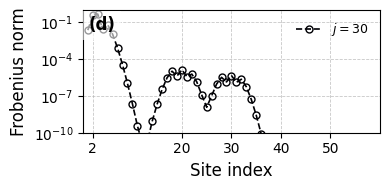

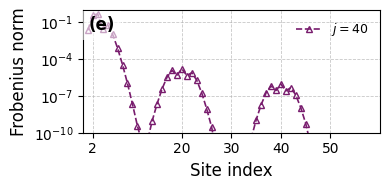

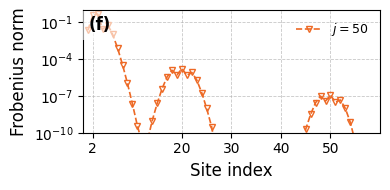

In [10]:
# -----------------------------
# Profiles: one figure for each v at t=1
# -----------------------------
letters = ["(d)", "(e)", "(f)"]
letterjdict = {vj: letter for vj, letter in zip(j_values, letters)}

cmap = plt.cm.inferno
colors = [cmap(i / 3) for i in range(len(j_values))]
markers = ["o", "^", "v", "x", "p", "*", "h"]

for idx, (v, c) in enumerate(zip(j_values, colors)):
    locA, locNA = frho_paths_for(v)

    frhoa = load_mathematica_data(locA)
    frhona = load_mathematica_data(locNA)

    frhoa = maybe_time_order(frhoa, col0_is_time=col0_is_time)
    frhona = maybe_time_order(frhona, col0_is_time=col0_is_time)

    rhoa = build_rho_per_site(frhoa, ns=ns, col0_is_time=col0_is_time)
    rhona = build_rho_per_site(frhona, ns=ns, col0_is_time=col0_is_time)

    F = frobenius_norm_delta(rhona, rhoa)  # [t, ns]

    t_idx = time_index_for_t(
        frhoa, time_for_profile,
        col0_is_time=col0_is_time,
        tInterval=tInterval
    )
    profile = F[t_idx, :]  # [ns]

    sites = np.arange(1, ns + 1, dtype=int)

    # Optional: remove tiny values for semilogy
    mask = profile > 1e-14
    sites_m = sites[mask]
    prof_m = profile[mask]

    plt.figure(figsize=(4, 2))

    plt.semilogy(
        sites_m, prof_m, "--",
        marker=markers[idx % len(markers)],
        markerfacecolor="none",
        markeredgecolor=c,
        color=c,
        linewidth=1.2,
        markersize=5,
        label=fr"$j={v}$"
    )

    plt.text(
        0.02, 0.95, letterjdict[v],
        transform=plt.gca().transAxes,
        fontsize=12, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.xticks([2, 20, 30, 40, 50, 100])
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel(r"Frobenius norm", fontsize=12)
    # plt.title(fr"$(2,20,j;3,20,{v})$", fontsize=12)
    plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
    plt.xlim(0, 60)
    plt.ylim(1e-10, 1)
    plt.legend(fontsize=9, loc="upper right", frameon=False)

    plt.tight_layout()
    plt.savefig(f"plt/Profile_t{time_for_profile}_j{v}.svg", dpi=600)
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b1varyJxa05OBC{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 10000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2;3), J_z={Jz:g},\ \alpha=0.5, OBC$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutionb1a05OBC.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=100
Rendering frame for Jx=200
Rendering frame for Jx=300
Rendering frame for Jx=400
Rendering frame for Jx=500
Rendering frame for Jx=600
Rendering frame for Jx=700
Rendering frame for Jx=800
Rendering frame for Jx=900
Rendering frame for Jx=1000
GIF saved to: gif\correlation_evolutionb1a05OBC.gif


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b1varyJxa05PBC{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 10000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2;3), J_z={Jz:g},\ \alpha=0.5, PBC$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutionb1a05PBC.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=100
Rendering frame for Jx=200
Rendering frame for Jx=300
Rendering frame for Jx=400
Rendering frame for Jx=500
Rendering frame for Jx=600
Rendering frame for Jx=700
Rendering frame for Jx=800
Rendering frame for Jx=900
Rendering frame for Jx=1000
GIF saved to: gif\correlation_evolutionb1a05PBC.gif


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2varyJxa05OBCKac{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 10000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2,14;3,14), J_z={Jz:g},\ \alpha=0.5, OBC, with Kac$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutiona05OBCKac.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=100
Rendering frame for Jx=200
Rendering frame for Jx=300
Rendering frame for Jx=400
Rendering frame for Jx=500
Rendering frame for Jx=600
Rendering frame for Jx=700
Rendering frame for Jx=800
Rendering frame for Jx=900
Rendering frame for Jx=1000
GIF saved to: gif\correlation_evolutiona05OBCKac.gif


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2varyJxa05PBCKac{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 10000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2,14;3,14), J_z={Jz:g},\ \alpha=0.5, PBC, with Kac$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutiona05PBCKac.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=100
Rendering frame for Jx=200
Rendering frame for Jx=300
Rendering frame for Jx=400
Rendering frame for Jx=500
Rendering frame for Jx=600
Rendering frame for Jx=700
Rendering frame for Jx=800
Rendering frame for Jx=900
Rendering frame for Jx=1000
GIF saved to: gif\correlation_evolutiona05PBCKac.gif


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2varyJxa05PBC{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 10000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2,14;3,14), J_z={Jz:g},\ \alpha=0.5, PBC$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutiona09.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=100
Rendering frame for Jx=200
Rendering frame for Jx=300
Rendering frame for Jx=400
Rendering frame for Jx=500
Rendering frame for Jx=600
Rendering frame for Jx=700
Rendering frame for Jx=800
Rendering frame for Jx=900
Rendering frame for Jx=1000
GIF saved to: gif\correlation_evolutiona09.gif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))
# # np.concatenate((
    
#     # ,
#     # np.arange(100, 1100, 100)
# ))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2varyJxa09{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 1000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2,14;3,14), J_z={Jz:g},\ \alpha=0.9$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutiona09.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
GIF saved to: gif\correlation_evolutiona09.gif


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((np.arange(10, 110, 10),np.arange(100, 1100, 100)))
# # np.concatenate((
    
#     # ,
#     # np.arange(100, 1100, 100)
# ))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2varyJxa05{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 1000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2,14;3,14), J_z={Jz:g},\ \alpha=0.5$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutiona05.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=100
D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\b2varyJxa05200CorrelationFunction.txt doesn't exist
D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\b2varyJxa05300CorrelationFunction.txt doesn't exist
D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\b2varyJxa05400CorrelationFunction.txt doesn't exist
D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\b2varyJxa05500CorrelationFunction.txt doesn't exist
D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\b2varyJxa05600CorrelationFunction.txt doesn't exist
D:\OneDrive - Tulane University\RESEA

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.arange(10, 110, 10)
# # np.concatenate((
    
#     # ,
#     # np.arange(100, 1100, 100)
# ))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2varyJxa0{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue/10}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 1000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$(2,14;3,14), J_z={Jz:g},\ \alpha=0.0$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolutiona0.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
GIF saved to: gif\correlation_evolutiona0.gif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import imageio.v2 as imageio
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.arange(10, 110, 10)
np.concatenate((
    np.arange(10, 110, 10),
    np.arange(400, 1100, 100)
))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
out_dir = r"gif"
os.makedirs(out_dir, exist_ok=True)

eps = 1e-4

# light-cone settings
Jz = 1.0
x0_site_right = 3.5
x0_site_left  = 17.5
t_line_points = 400

use_site_centered_extent = True
xticks_sites = np.array([1, 5, 13])

frames = []  # for GIF

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2vayJx{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Rendering frame for Jx={avalue}")

    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]

    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        extent = [0.0, float(n_sites), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites)
    else:
        extent = [0.0, float(n_sites - 1), t_min, t_max]
        x_min, x_max = 0.0, float(n_sites - 1)

    fig, ax = plt.subplots(figsize=(5, 3))

    im = ax.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=1),
        extent=extent,
        rasterized=True
    )

    # Panel label
    ax.text(
        0.02, 0.95, f"$J_x={avalue}$",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Velocity choice
    v = 4 * Jz if avalue == 1000 else 2 * Jz

    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray
    x_line_right = x0_site_right + v * t_line
    mask = (x_line_right >= x_min) & (x_line_right <= x_max)

    ax.plot(
        x_line_right[mask], t_line[mask],
        linestyle="--", color="black", linewidth=1.6, zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Correlation function|")

    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    if use_site_centered_extent:
        ax.set_xticks(xticks_sites - 0.5)
        ax.set_xticklabels([str(x) for x in xticks_sites])

    ax.set_title(fr"$J_z={Jz:g},\ \alpha=0.5$")

    plt.tight_layout()

    # -----------------------------
    # Save frame
    # -----------------------------
    frame_path = os.path.join(out_dir, f"frame_Jx_{avalue:04d}.png")
    plt.savefig(frame_path, dpi=200)
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

# -----------------------------
# Build GIF
# -----------------------------
gif_path = os.path.join(out_dir, "correlation_evolution.gif")
imageio.mimsave(gif_path, frames, duration=0.7)

print(f"GIF saved to: {gif_path}")

Rendering frame for Jx=10
Rendering frame for Jx=20
Rendering frame for Jx=30
Rendering frame for Jx=40
Rendering frame for Jx=50
Rendering frame for Jx=60
Rendering frame for Jx=70
Rendering frame for Jx=80
Rendering frame for Jx=90
Rendering frame for Jx=100
Rendering frame for Jx=400
Rendering frame for Jx=500
Rendering frame for Jx=600
Rendering frame for Jx=700
Rendering frame for Jx=800
Rendering frame for Jx=900
Rendering frame for Jx=1000
GIF saved to: gif\correlation_evolution.gif


Found: D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\b2vayJx10CorrelationFunction.txt


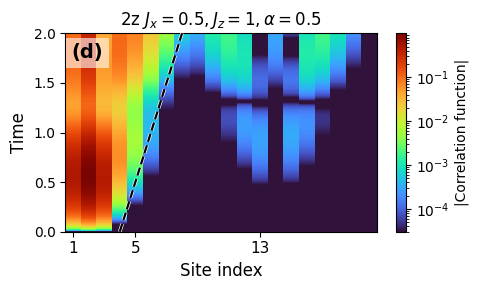

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import os

# -----------------------------
# User settings
# -----------------------------
avalue_arr = np.concatenate((
    np.arange(10, 100, 10),
    np.arange(100, 1100, 100)
    # ,    np.arange(1000, 3000, 1000)
))

base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
eps = 3e-5

# light-cone settings
Jz = 1.0  # <-- set as needed
x0_site_right = 3.5  # site-centered origin (site 19 ~ 18.5 on imshow with -0.5 alignment)
x0_site_left  = 17.5  # left-moving ray origin
t_line_points = 400

# If you want site-centered alignment like your other plot:
# We'll use extent x=[0, Nsites], and ticks at (site-0.5).
use_site_centered_extent = True

# Optional: custom xticks (site numbers)
xticks_sites = np.array([1, 5, 13])

# -----------------------------
# Plot loop
# -----------------------------
for avalue in avalue_arr:

    filename = f"b2vayJx{avalue}CorrelationFunction.txt"
    file_path = os.path.join(base_path, filename)

    if not os.path.exists(file_path):
        print(f"{file_path} doesn't exist")
        continue

    print(f"Found: {file_path}")

    # Load data
    data = np.loadtxt(file_path)
    time = data[:, 0]
    corr = data[:, 1:]  # shape (T, Nsites)

    # log-scale magnitude (your /1000 normalization retained)
    corr_abs = np.abs(corr)
    corr_clip = np.clip(corr_abs, eps, None)

    # axes extents
    t_min, t_max = time.min(), time.max()
    n_sites = corr_clip.shape[1]

    if use_site_centered_extent:
        # x runs 0..Nsites, and "site i" centered at i-0.5
        x_min, x_max = 0.0, float(n_sites)
        extent = [x_min, x_max, t_min, t_max]
    else:
        # x runs 0..Nsites-1
        x_min, x_max = 0.0, float(n_sites - 1)
        extent = [x_min, x_max, t_min, t_max]

    plt.figure(figsize=(5, 3))

    im = plt.imshow(
        corr_clip,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=eps, vmax=np.nanmax(corr_clip)),
        extent=extent,
        rasterized=True
    )

    # -----------------------------
    # Panel label (optional)
    # -----------------------------
    label = "(d)" if avalue == avalue_arr[0] else "(c)"
    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # -----------------------------
    # Velocity choice (copying your logic)
    # -----------------------------
    if avalue == 1000:
        v = 4 * Jz
    else:
        v = 2 * Jz

    # -----------------------------
    # Light-cone rays
    # -----------------------------
    t_line = np.linspace(t_min, t_max, t_line_points)

    # Right-moving ray from x0_site_right
    x_line_right = x0_site_right + v * t_line
    mask_right = (x_line_right >= x_min) & (x_line_right <= x_max)

    plt.plot(
        x_line_right[mask_right], t_line[mask_right],
        linestyle="--",
        color="black",
        linewidth=1.6,
        zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),  # white outline
            pe.Normal()
        ]
    )

    # Left-moving ray from x0_site_left (white dashed)
    x_line_left = x0_site_left - v * t_line
    mask_left = (x_line_left >= x_min) & (x_line_left <= x_max)

    # plt.plot(
    #     x_line_left[mask_left], t_line[mask_left],
    #     linestyle="--",
    #     color="white",
    #     linewidth=1.6,
    #     zorder=6,
    #     path_effects=[
    #         pe.Stroke(linewidth=2.2, foreground="black"),  # optional black outline so white stays visible
    #         pe.Normal()
    #     ]
    # )

    # -----------------------------
    # Colorbar + labels
    # -----------------------------
    plt.colorbar(im, label="|Correlation function|")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)

    # Title (edit as needed)
    alpha_label = r"\infty" if avalue == 1000 else "0.1"
    plt.title(fr"2z $J_{{x}}=0.5, J_z={Jz:g}, \alpha={0.5}$", fontsize=12)

    # X ticks aligned to site centers like your other plot
    if use_site_centered_extent:
        plt.xticks(xticks_sites - 0.5, [str(x) for x in xticks_sites], fontsize=11)

    plt.tight_layout()

    # Optional save (uncomment)
    # plt.savefig(f"plt/zinit{avalue}.svg", dpi=600)

    plt.show()


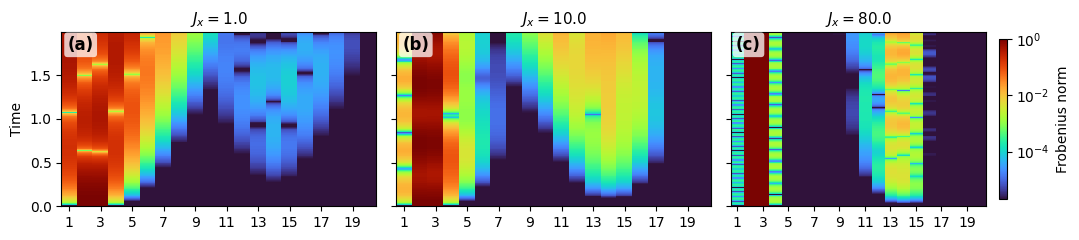

In [27]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# Load Mathematica-style data (robust)
# ============================================================
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = (
                line.replace("*^", "e")
                    .strip()
                    .lstrip("{")
                    .rstrip("}")
            )
            if not line:
                continue

            row = []
            for e in line.split(","):
                e = e.strip()
                e = e.split("+")[0].strip().lstrip("{").rstrip("}")

                if "I" in e:
                    continue

                try:
                    row.append(float(e))
                except ValueError:
                    pass

            if row:
                data.append(row)

    return np.array(data, dtype=float)

# ============================================================
# Parameters
# ============================================================
varyVariableList = np.concatenate((
    np.arange(10, 100, 10),
    np.arange(100, 900, 100)
))

src_dir = "src"
step_size = 0.01
steps_per_unit = 1.0 / step_size

vmin = 2e-6
vmax = 1.0
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# ------------------------------------------------------------
# Pick three representative values: first, middle, last
# ------------------------------------------------------------
selected_vars = [
    varyVariableList[0],
    varyVariableList[len(varyVariableList)//2+1],
    varyVariableList[-1]
]

panel_labels = ["(a)", "(b)", "(c)"]

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(11, 2.5), sharey=True)

im = None
for ax, variable, lab in zip(axes, selected_vars, panel_labels):
    path = os.path.join(src_dir, f"b2varyJx{variable}.txt")
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    data = load_mathematica_data(path)
    data = np.nan_to_num(data, nan=vmin, posinf=vmin, neginf=vmin)
    data[data < vmin] = vmin

    n_steps, L = data.shape
    time_axis = np.arange(n_steps) / steps_per_unit
    Jx = variable / 10.0

    im = ax.imshow(
        data,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=norm,
        extent=[0, L, time_axis.min(), time_axis.max()],
        interpolation="none",
    )

    ax.set_title(rf"$J_x={Jx:.1f}$", fontsize=11)

    ax.text(
        0.02, 0.98, lab,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.2"
        )
    )

    ax.set_xlim(0, L)
    # ticks at sites 1,3,5,...,L (1-based, step 2)
    xticks = np.arange(0.5, L+0.5, 2)          # pixel-centered positions
    xticklabels = np.arange(1, L + 1, 2) # physical site labels

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

# shared labels
axes[0].set_ylabel("Time")

# shared colorbar
cbar = fig.colorbar(im, ax=axes[-1], shrink=0.92, pad=0.04)
cbar.set_label("Frobenius norm")

fig.tight_layout()
plt.savefig("plt/confinementLC.svg")
plt.show()

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import imageio.v2 as imageio  # pip install imageio

# ============================================================
# Load Mathematica-style data
# ============================================================
def load_mathematica_data(filename):
    """
    Load data from a Mathematica-style text file:
    {0.001 + 0.*I, 5.6*^-9 + 0.*I, ...}
    Returns: 2D numpy array (time x site)
    """
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e")
            line = line.strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip().split("+")[0].strip()
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data, dtype=float)

# ============================================================
# Parameters
# ============================================================
varyVariableList = np.concatenate((
    np.arange(10, 100, 10),
    np.arange(100, 1100, 100)
    # ,    np.arange(1000, 3000, 1000)
))

src_dir = "src"
out_gif = "b2_varyJx_heatmaps.gif"

step_size = 0.01
steps_per_unit = 1.0 / step_size

vmin = 1e-4

# ============================================================
# Compute global vmax (for consistent color scale)
# ============================================================
global_vmax = 1

for variable in varyVariableList:
    path = os.path.join(src_dir, f"b2varyJx{variable}.txt")
    if not os.path.exists(path):
        print(f"[WARN] missing file: {path}")
        continue

    tmp = load_mathematica_data(path)
    tmp = np.nan_to_num(tmp, nan=vmin, posinf=vmin, neginf=vmin)
    tmp[tmp < vmin] = vmin

    # global_vmax = max(global_vmax, tmp.max())

if global_vmax <= vmin:
    raise RuntimeError("No valid data found — check input files.")

norm = mcolors.LogNorm(vmin=vmin, vmax=global_vmax)

# ============================================================
# Build GIF frames
# ============================================================
frames = []

for variable in varyVariableList:
    data_path = os.path.join(src_dir, f"b2varyJx{variable}.txt")
    if not os.path.exists(data_path):
        print(f"[SKIP] missing file: {data_path}")
        continue

    raw_data = load_mathematica_data(data_path)

    # --- Clip data for LogNorm ---
    raw_plot = np.nan_to_num(raw_data, nan=vmin, posinf=vmin, neginf=vmin)
    raw_plot[raw_plot < vmin] = vmin

    n_steps = raw_plot.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = float(time_axis.min()), float(time_axis.max())

    Jx = variable / 10.0

    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(
        raw_plot,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="none",
        norm=norm,
        extent=[0, raw_plot.shape[1], t_min, t_max]
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Frobenius norm", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    ax.set_xlabel("Site index", fontsize=12)
    ax.set_ylabel("Time", fontsize=12)
    ax.set_title(
        rf"(2,14;3,14), $J_z=1,\; J_x={Jx:.1f},\; \alpha=0.5$",
        fontsize=11
    )

    # Centered site ticks
    n_sites = raw_plot.shape[1]
    step = 2
    positions = np.arange(0.5, n_sites, step)
    labels = np.arange(1, n_sites + 1, step)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

    ax.text(
        0.06, 0.95, rf"$J_x={Jx:.1f}$",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        bbox=dict(facecolor="white", edgecolor="none",
                  alpha=0.75, boxstyle="round,pad=0.2")
    )

    fig.tight_layout()

    # ========================================================
    # Frame capture (Matplotlib >= 3.8 safe)
    # ========================================================
    fig.canvas.draw()
    frame_rgba = np.asarray(fig.canvas.buffer_rgba())
    frame_rgb = frame_rgba[:, :, :3].copy()
    frames.append(frame_rgb)

    plt.close(fig)

# ============================================================
# Save GIF
# ============================================================
if not frames:
    raise RuntimeError("No frames produced.")

imageio.mimsave(out_gif, frames, duration=2)
print(f"Saved GIF → {out_gif}")

Saved GIF → b2_varyJx_heatmaps.gif


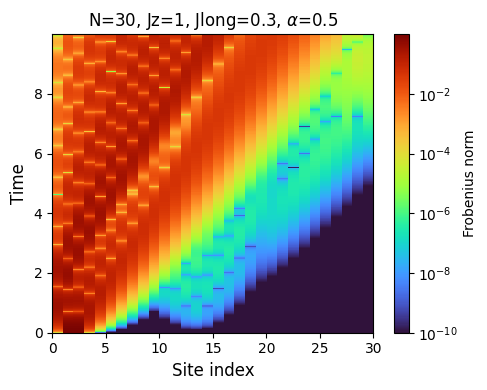

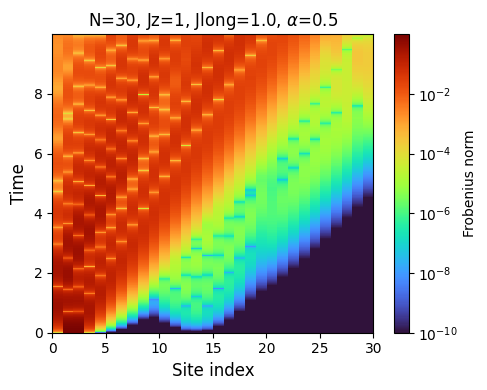

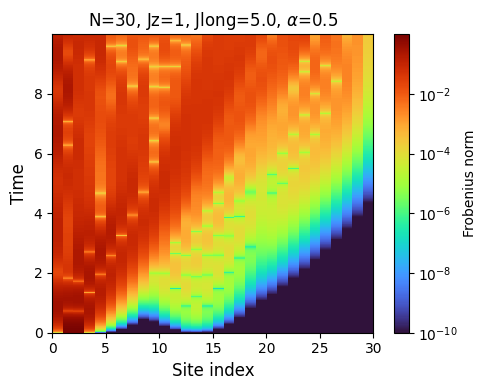

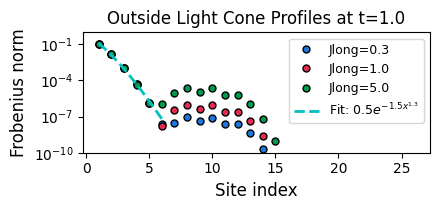

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = [3, 10, 50]
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1.0

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
all_max = 0
for J in Jlong_values:
    data = load_mathematica_data(os.path.join(base_path, f"N30B0LFIMb2lcfarVaryJlong{J}.txt"))
    all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N30B0LFIMb2lcfarVaryJlong{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 4))
    im = plt.imshow(
    np.clip(raw_data, 1e-10, None),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    norm=mcolors.LogNorm(vmin=1e-10, vmax=all_max),
    interpolation="nearest",   # 👈 No smoothing
    extent=[0, raw_data.shape[1], t_min, t_max],
    rasterized=True            # 👈 Forces raster pixels in SVG/PDF
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"N=30, Jz=1, Jlong={J/10:.1f}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_Jlong{J}.svg", dpi=600)
    plt.show()

# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 2.2))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"N30B0LFIMb2lcfarVaryJlong{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 4:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 6
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    plt.semilogy(sites, profile, "o", color=c, markersize=5,
                 markeredgecolor="k", label=f"Jlong={J/10:.1f}")

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlabel("Site index", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plt/Profiles_Overlayed_GlobalFit.svg", dpi=600)
plt.show()


t = 0.10 → slope = 2.000
t = 0.50 → slope = 2.000
t = 2.00 → slope = 1.984


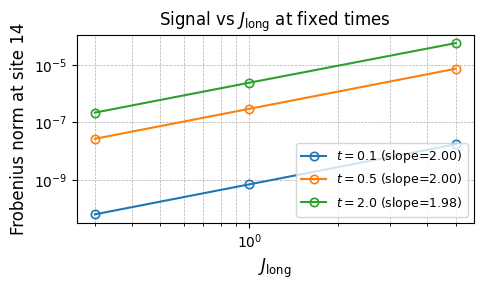

In [ ]:
# -----------------------------
# Plot: Site 14 value vs Jlong at fixed times (log-log)
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

fixed_times = [0.1, 0.5, 2.0]
site_index = 13  # site 14 (0-based)
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(5, 3))

for t_fixed, c in zip(fixed_times, colors):
    values_at_t = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"N30B0LFIMb2lcfarVaryJlong{J}.txt")
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit

        # Find the closest time index
        idx = np.argmin(np.abs(time_axis - t_fixed))
        val = raw_data[idx, site_index]
        values_at_t.append(val)

    # Convert to arrays for fitting
    J_vals = np.array(Jlong_values) / 10.0
    y_vals = np.array(values_at_t)

    # Fit log(y) = m * log(J) + b  → slope = m
    mask = (y_vals > 1e-14)
    if np.sum(mask) >= 2:
        slope, intercept = np.polyfit(np.log(J_vals[mask]), np.log(y_vals[mask]), 1)
        print(f"t = {t_fixed:>4.2f} → slope = {slope:.3f}")
    else:
        slope = np.nan
        print(f"t = {t_fixed:>4.2f} → insufficient valid points")

    plt.loglog(
        J_vals, y_vals,
        "o-", color=c,
        markerfacecolor='none',
        markeredgewidth=1.2,
        label=fr"$t={t_fixed}$ (slope={slope:.2f})"
    )

plt.xlabel(r"$J_{\mathrm{long}}$", fontsize=12)
plt.ylabel("Frobenius norm at site 14", fontsize=12)
plt.title("Signal vs $J_{\\mathrm{long}}$ at fixed times", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.savefig("plt/Site14_vs_Jlong_fixed_times.svg", dpi=600)
plt.show()


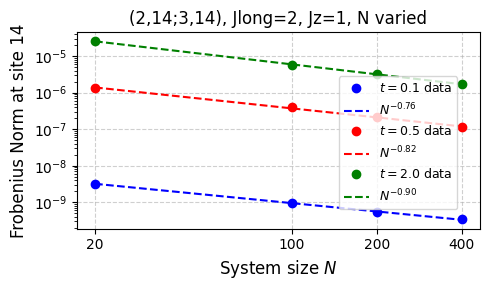

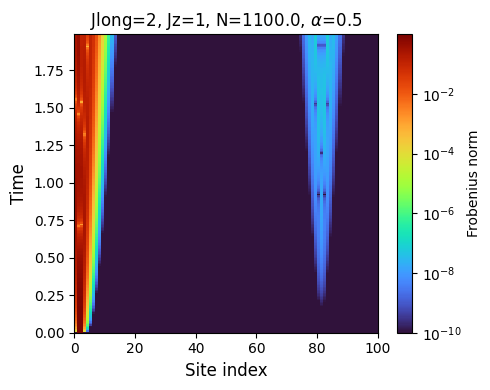

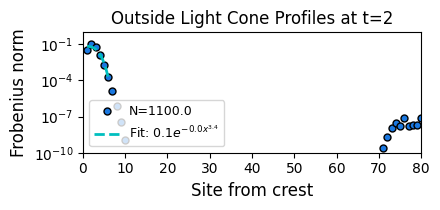

In [54]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = [1100]
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
all_max = 0
for J in Jlong_values:
    data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryN{J}.txt"))
    all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05VaryN{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 4))
    im = plt.imshow(
    np.clip(raw_data, 1e-10, None),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    norm=mcolors.LogNorm(vmin=1e-10, vmax=all_max),
    interpolation="nearest",   # 👈 No smoothing
    extent=[0, raw_data.shape[1], t_min, t_max],
    rasterized=True            # 👈 Forces raster pixels in SVG/PDF
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"Jlong=2, Jz=1, N={J:.1f}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N{J}.svg", dpi=600)
    plt.show()

# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 2.2))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05VaryN{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 4:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 6
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    plt.semilogy(sites, profile, "o", color=c, markersize=5,
                 markeredgecolor="k", label=f"N={J:.1f}")

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlim(0, 80)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_VaryN.svg", dpi=600)
plt.show()


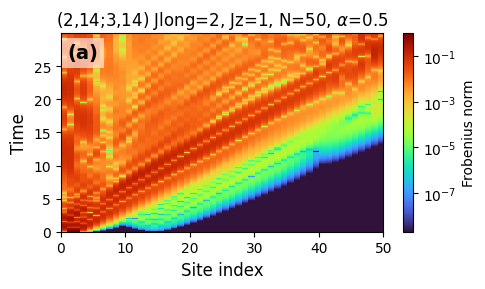

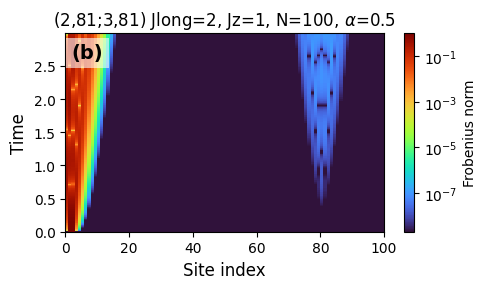

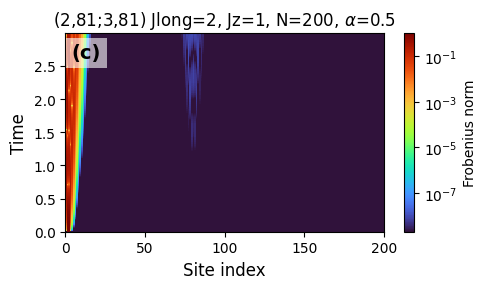

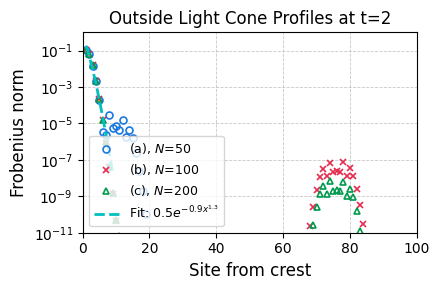

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = [50,100,200]
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
all_max = 0
for J in Jlong_values:
    data = load_mathematica_data(os.path.join(base_path, f"N{J}B0LFIMHeffb2lcalpha05farPlot.txt"))
    all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N{J}B0LFIMHeffb2lcalpha05farPlot.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
    np.clip(raw_data, 1e-11, None),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    norm=mcolors.LogNorm(vmin=2e-9, vmax=all_max),
    interpolation="nearest",   # 👈 No smoothing
    extent=[0, raw_data.shape[1], t_min, t_max],
    rasterized=True            # 👈 Forces raster pixels in SVG/PDF
    )

    # Determine subfigure label based on index
    label = {50: "(a)", 100: "(b)", 200: "(c)"}[J]

    # Add label in top-left corner of the plot
    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"(2,81;3,81) Jlong=2, Jz=1, N={J:.0f}, $\alpha$=0.5", fontsize=12)
    if J == 50:
        plt.title(fr"(2,14;3,14) Jlong=2, Jz=1, N={J:.0f}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N{J}.svg", dpi=600)
    plt.show()

# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)']
let=0
# Define marker styles (extend or reorder as needed)
markers = ["o", "x", "^", "D", "v", "<", ">", "P",  "*"]

for J, c, m in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"N{J}B0LFIMHeffb2lcalpha05farPlot.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 5:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 9
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    plt.semilogy(
        sites, profile,
        marker=m,
        markerfacecolor='none',  # open marker
        markeredgecolor=c,
        markeredgewidth=1.2,
        markersize=5,
        linestyle="None",
        color=c,
        label=fr"{letters[let]}, $N$={J}"
    )

    let += 1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-11, 1)
plt.xlim(0, 100)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_VaryN.svg", dpi=600)
plt.show()


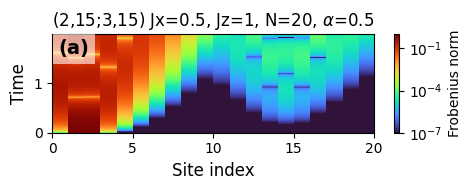

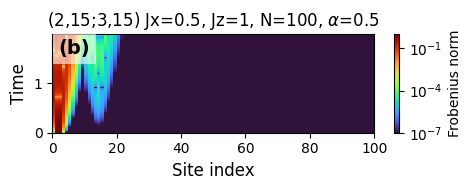

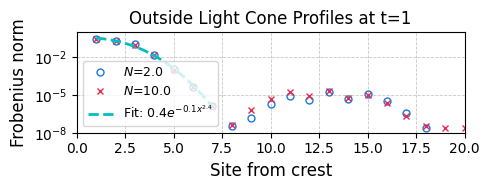

In [16]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([20,100])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"Jx05LFIMHeffb2lcalpha05farN{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2))
    im = plt.imshow(
        np.clip(raw_data, 1e-14, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-7, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label = {20: "(a)", 100: "(b)", 200: "(c)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"(2,15;3,15) Jx=0.5, Jz=1, N={J}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_Jx05N{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)']
let=0
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"Jx05LFIMHeffb2lcalpha05farN{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit =8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    if J ==20:
        plt.semilogy(
        sites, profile, "o",
        markerfacecolor='none',     # open circles (no fill)
        markeredgecolor=c,          # colored edges
        markersize=5,
        label=fr"$N$={J/10:.1f}"
        )   
    else:
        plt.semilogy(
        sites, profile, "x",
        markerfacecolor='none',     # open squares (no fill)
        markeredgecolor=c,          # colored edges
        markersize=5,
        label=fr"$N$={J/10:.1f}"
        )
    let+=1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-7
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-8, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_Jx05VaryN2.svg", dpi=600)
plt.show()


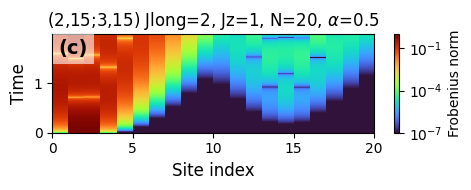

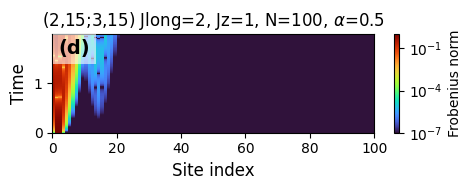

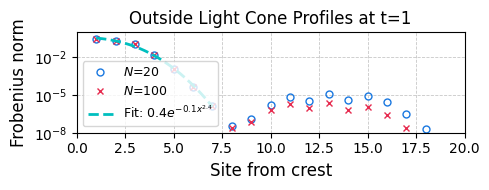

In [17]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([20,100])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"Jlong2LFIMHeffb2lcalpha05farN{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2))
    im = plt.imshow(
        np.clip(raw_data, 1e-14, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-7, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label = {20: "(c)", 100: "(d)", 200: "(c)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"(2,15;3,15) Jlong=2, Jz=1, N={J}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_Jlong2N{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)']
let=0
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"Jlong2LFIMHeffb2lcalpha05farN{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit =8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    if J ==20:
        plt.semilogy(
        sites, profile, "o",
        markerfacecolor='none',     # open circles (no fill)
        markeredgecolor=c,          # colored edges
        markersize=5,
        label=fr"$N$={J/1:.0f}"
        )
    else:
        plt.semilogy(
        sites, profile, "x",
        markerfacecolor='none',     # open circles (no fill)
        markeredgecolor=c,          # colored edges
        markersize=5,
        label=fr"$N$={J/1:.0f}"
        )   
    let+=1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-7
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-8, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_Jlong2VaryN2.svg", dpi=600)
plt.show()


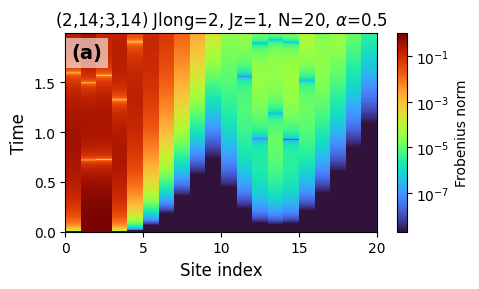

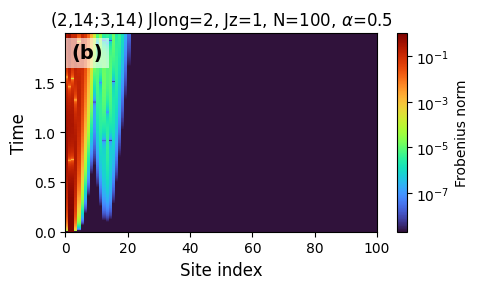

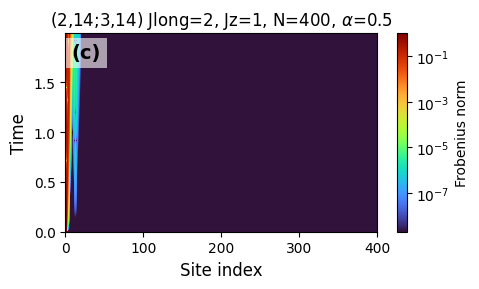

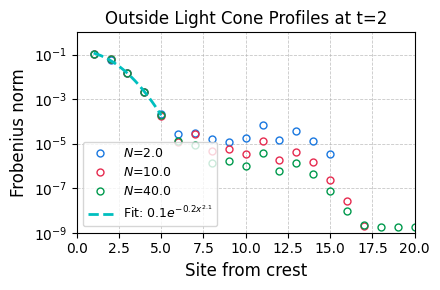

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([20,100,400])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=2e-9, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label = {20: "(a)", 100: "(b)", 400: "(c)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"(2,14;3,14) Jlong=2, Jz=1, N={J}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)']
let=0
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 5:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit =5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    plt.semilogy(
    sites, profile, "o",
    markerfacecolor='none',     # open circles (no fill)
    markeredgecolor=c,          # colored edges
    markersize=5,
    label=fr"$N$={J/10:.1f}"
    )   
    let+=1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-9, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_VaryN2.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


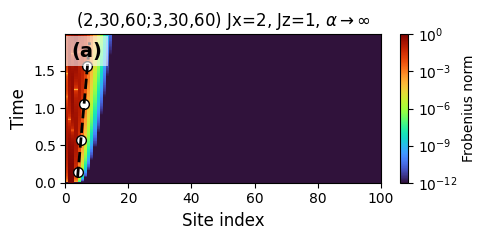

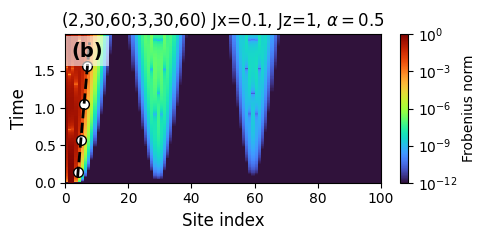

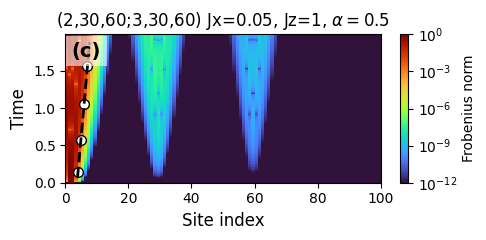

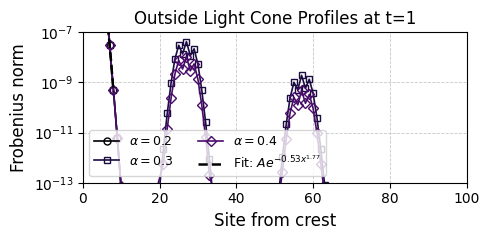

In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([2,3,4])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N100b3varyalphanoKac{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-12, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 100)
    plt.title(fr"(2,30,60;3,30,60) Jx=0.05, Jz=1, $\alpha=0.5$", fontsize=12)
    if J == 3:
         plt.title(fr"(2,30,60;3,30,60) Jx=0.1, Jz=1, $\alpha=0.5$", fontsize=12)
    if J == 2:
         plt.title(fr"(2,30,60;3,30,60) Jx=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha2{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"N100b3varyalphanoKac{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-13, 1e-7)
plt.xlim(0, 100)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryAlpha3.svg", dpi=600)
plt.show()



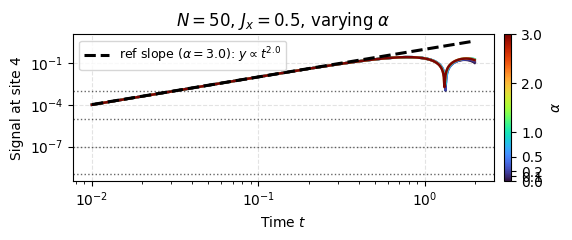

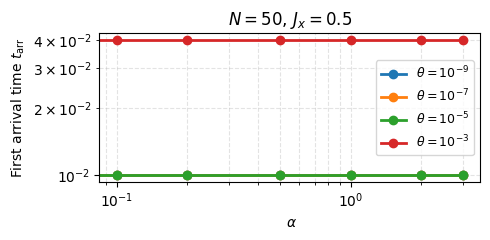

In [31]:
from matplotlib.colors import Normalize
import numpy as np
import os
import matplotlib.pyplot as plt


def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)


# -----------------------------
# Settings
# -----------------------------
# ⬇⬇⬇ 1000 REMOVED  100⬇⬇⬇
alpha_tags = np.array([0, 1, 2, 5, 10, 20, 30])
base_path = "src"

N_system = 50
Jx_fixed = 0.5

site_of_interest = 3
tInterval = 0.01

# slope fit
t_fit_min = 1e-2
t_fit_max = 0.2
tag_ref = 30
anchor_t = 0.1

thresholds = [1e-9, 1e-7, 1e-5, 1e-3]

# -----------------------------
# Map tags → alpha
# -----------------------------
alpha_vals = alpha_tags / 10.0
norm = Normalize(vmin=alpha_vals.min(), vmax=alpha_vals.max())
cmap = plt.cm.turbo


# -----------------------------
# Load data (filenames unchanged)
# -----------------------------
series = {}
Tmin = None

for tag in alpha_tags:
    fn = os.path.join(base_path, f"N50b3varyalphanoKac{tag}.txt")
    raw = load_mathematica_data(fn)

    if raw.size == 0:
        print(f"[WARN] Empty file: {fn}")
        continue

    y = raw[:, site_of_interest]
    series[tag] = y
    Tmin = len(y) if Tmin is None else min(Tmin, len(y))

t = np.arange(Tmin) * tInterval


# -----------------------------
# Fit slope on reference curve
# -----------------------------
t_line = y_line = None
p = np.nan

if tag_ref in series:
    y_ref = series[tag_ref][:Tmin]
    mask = (t >= t_fit_min) & (t <= t_fit_max) & (y_ref > 0)

    if np.sum(mask) >= 3:
        p, _ = np.polyfit(np.log(t[mask]), np.log(y_ref[mask]), 1)

        ti0 = int(round(anchor_t / tInterval))
        ti0 = np.clip(ti0, 0, Tmin - 1)
        C = y_ref[ti0] / (t[ti0] ** p)

        t_line = np.geomspace(t_fit_min, t[-1], 400)
        y_line = C * t_line ** p


# -----------------------------
# 1) Time traces vs t
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 2.5))

for tag, a in zip(alpha_tags, alpha_vals):
    y = series[tag][:Tmin]
    m = (t > 0) & (y > 0)
    ax.loglog(t[m], y[m], lw=1.8, color=cmap(norm(a)))

if t_line is not None:
    ax.loglog(
        t_line, y_line, "k--", lw=2.2,
        label=rf"ref slope ($\alpha={tag_ref/10:.1f}$): $y\propto t^{{{p:.1f}}}$"
    )

for th in thresholds:
    ax.axhline(th, color="k", lw=1.0, ls=":", alpha=0.6)

ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"Signal at site 4")
ax.set_title(rf"$N={N_system}$, $J_x={Jx_fixed}$, varying $\alpha$")
ax.grid(True, linestyle="--", alpha=0.35)

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\alpha$")
cbar.set_ticks(alpha_vals)
cbar.set_ticklabels([f"{a:.1f}" for a in alpha_vals])
cbar.ax.minorticks_off()

if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/timeArrVaryAlpha1.svg", dpi=600)
plt.show()


# -----------------------------
# 2) Arrival times vs alpha
# -----------------------------
arrival = {th: [] for th in thresholds}

for tag in alpha_tags:
    y = series[tag][:Tmin]
    for th in thresholds:
        idx = np.where(y >= th)[0]
        arrival[th].append(np.nan if len(idx) == 0 else idx[0] * tInterval)

fig, ax = plt.subplots(figsize=(5, 2.5))

for th in thresholds:
    tarr = np.array(arrival[th])
    m = np.isfinite(tarr) & (tarr > 0)
    ax.loglog(alpha_vals[m], tarr[m], "o-", lw=2, ms=6,
              label=rf"$\theta=10^{{{int(np.log10(th))}}}$")

ax.set_xlabel(r" $\alpha$")
ax.set_ylabel(r"First arrival time $t_{\mathrm{arr}}$")
ax.set_title(rf"$N={N_system}$, $J_x={Jx_fixed}$")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/timeArrVaryAlpha2.svg", dpi=600)
plt.show()


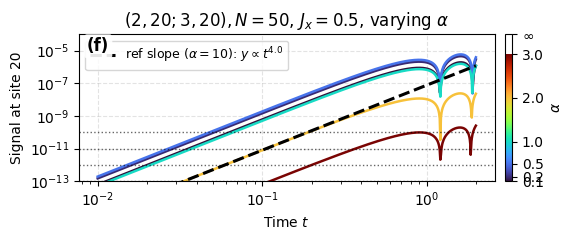

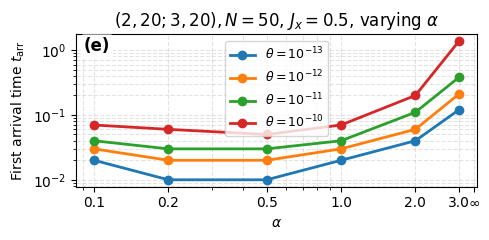

In [6]:
from matplotlib.colors import Normalize
import numpy as np
import os
import matplotlib.pyplot as plt


def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)


# -----------------------------
# Settings
# -----------------------------
# File tags (keep filenames unchanged)
alpha_tags = np.array([1, 2, 5, 10, 20, 30]) #, 100, 1000
base_path = "src"

N_system = 50
Jx_fixed = 0.5

site_of_interest = 19
tInterval = 0.01

# slope fit
t_fit_min = 1e-2
t_fit_max = 0.2
tag_ref = 20
anchor_t = 0.1

thresholds = [1e-13, 1e-12, 1e-11, 1e-10]

# -----------------------------
# Map tags → alpha (with ∞)
# -----------------------------
alpha_vals = np.array([
    np.inf if tag == 1000 else tag / 10.0
    for tag in alpha_tags
])

# For COLOR ONLY: replace ∞ by a finite cap
alpha_finite = alpha_vals[np.isfinite(alpha_vals)]
alpha_cap = alpha_finite.max() * 1.15
alpha_for_color = np.where(np.isinf(alpha_vals), alpha_cap, alpha_vals)

norm = Normalize(vmin=alpha_for_color.min(), vmax=alpha_for_color.max())
cmap = plt.cm.turbo


# -----------------------------
# Load data
# -----------------------------
series = {}
Tmin = None

for tag in alpha_tags:
    fn = os.path.join(base_path, f"N50b3varyalphanoKac{tag}.txt")
    raw = load_mathematica_data(fn)

    if raw.size == 0:
        print(f"[WARN] Empty file: {fn}")
        continue

    y = raw[:, site_of_interest]
    series[tag] = y
    Tmin = len(y) if Tmin is None else min(Tmin, len(y))

t = np.arange(Tmin) * tInterval


# -----------------------------
# Fit slope on reference curve
# -----------------------------
t_line = y_line = None
p = np.nan

if tag_ref in series:
    y_ref = series[tag_ref][:Tmin]
    mask = (t >= t_fit_min) & (t <= t_fit_max) & (y_ref > 0)

    if np.sum(mask) >= 3:
        p, _ = np.polyfit(np.log(t[mask]), np.log(y_ref[mask]), 1)
        ti0 = int(round(anchor_t / tInterval))
        ti0 = np.clip(ti0, 0, Tmin - 1)
        C = y_ref[ti0] / (t[ti0] ** p)
        t_line = np.geomspace(t_fit_min, t[-1], 400)
        y_line = C * t_line ** p

# --- Panel-letter helper (Nature-ish) ---
def panel_label(ax, letter, x=0.02, y=0.98):
    ax.text(
        x, y, letter,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold",
        color="k",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.9),
        zorder=10,
    )

# -----------------------------
# 1) Time traces vs t
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 2.5))
panel_label(ax, "(f)")


for tag, a_col in zip(alpha_tags, alpha_for_color):
    y = series[tag][:Tmin]
    m = (t > 0) & (y > 0)
    ax.loglog(t[m], y[m], lw=1.8, color=cmap(norm(a_col)))

if t_line is not None:
    ax.loglog(
        t_line, y_line, "k--", lw=2.2,
        label=rf"ref slope ($\alpha=10$): $y\propto t^{{{p:.1f}}}$"
    )

for th in thresholds:
    ax.axhline(th, color="k", lw=1.0, ls=":", alpha=0.6)

ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"Signal at site 20")
ax.set_ylim(1e-13, 1e-4)
ax.set_title(rf"$(2,20;3,20), N={N_system}$, $J_x={Jx_fixed}$, varying $\alpha$")
ax.grid(True, linestyle="--", alpha=0.35)

# -----------------------------
# Colorbar (linear, with ∞ tick)
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\alpha$")

alpha_ticks = list(alpha_finite) + [alpha_cap]
alpha_labels = [f"{a:.1f}" for a in alpha_finite] + [r"$\infty$"]

cbar.set_ticks(alpha_ticks)
cbar.set_ticklabels(alpha_labels)
cbar.ax.minorticks_off()

if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/timeArrVaryAlpha3.svg", dpi=600)
plt.show()


# -----------------------------
# 2) Arrival times vs alpha
# -----------------------------
arrival = {th: [] for th in thresholds}

for tag in alpha_tags:
    y = series[tag][:Tmin]
    for th in thresholds:
        idx = np.where(y >= th)[0]
        arrival[th].append(np.nan if len(idx) == 0 else idx[0] * tInterval)

fig, ax = plt.subplots(figsize=(5, 2.5))
panel_label(ax, "(e)")


for th in thresholds:
    tarr = np.array(arrival[th])
    m = np.isfinite(tarr) & (tarr > 0)
    ax.loglog(alpha_for_color[m], tarr[m], "o-", lw=2, ms=6,
                label=rf"$\theta=10^{{{int(np.log10(th))}}}$")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"First arrival time $t_{\mathrm{arr}}$")
ax.set_title(rf"$(2,20;3,20), N={N_system}$, $J_x={Jx_fixed}$, varying $\alpha$")
ax.grid(True, which="both", linestyle="--", alpha=0.35)

ax.set_xticks(alpha_ticks)
ax.set_xticklabels(alpha_labels)

ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig("plt/timeArrVaryAlpha4.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


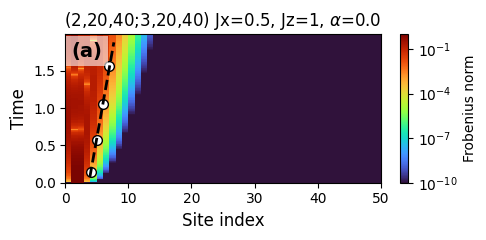

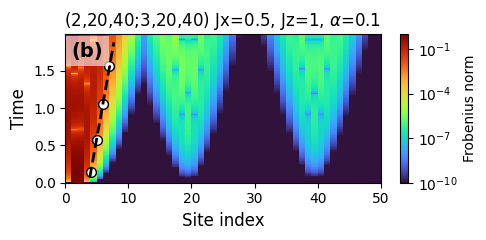

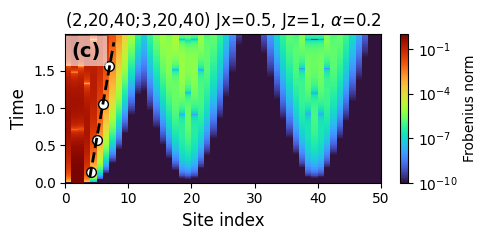

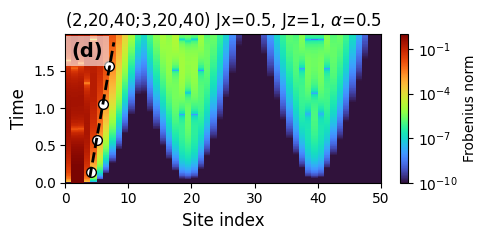

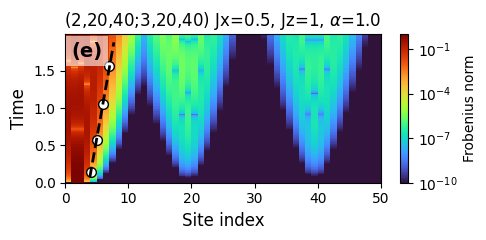

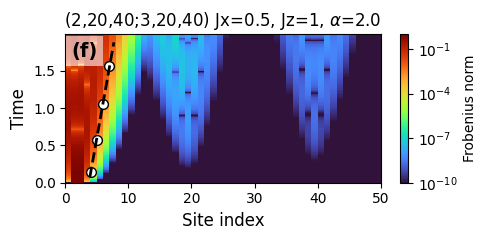

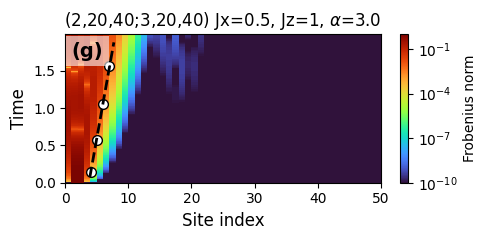

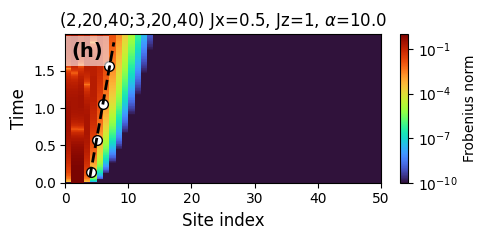

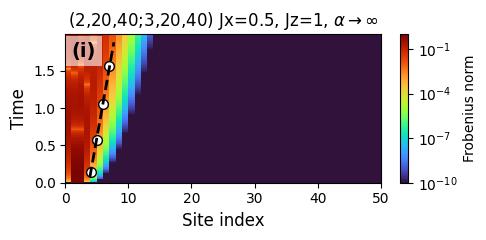

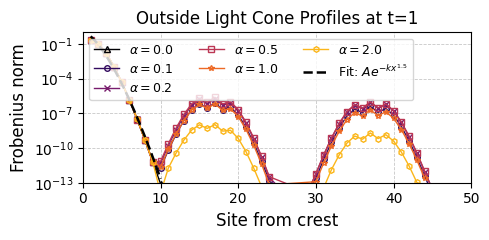

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# ----------------------------- 
Jlong_values = np.array([0, 1, 2, 5, 10, 20, 30,100, 1000]) #0, 1, 5, 20, 30, 1000
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N50b3varyalphanoKac{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)
    plt.title(fr"(2,20,40;3,20,40) Jx=0.5, Jz=1, $\alpha$={J/10:.1f}", fontsize=12)
    if J == 1000:
         plt.title(fr"(2,20,40;3,20,40) Jx=0.5, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 6) for i in range(0,6)]

# Six distinct markers
markers = [ "^", "o", "x",  "s",  "*", "h"] #, "v", "D", "p",


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"N50b3varyalphanoKac{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 10
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=4,
        linewidth=1,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-kx^{{{p_fit:.1f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-13, 1)
plt.xlim(0, 50)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper left", ncol=3, frameon=True)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryAlpha.svg", dpi=600)
plt.show()



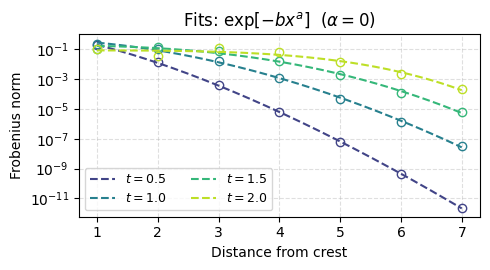

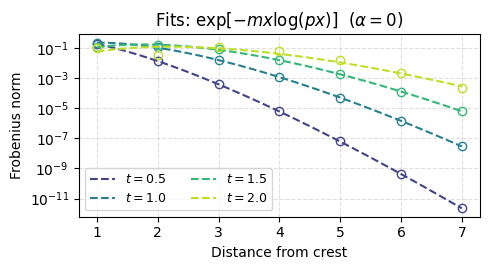

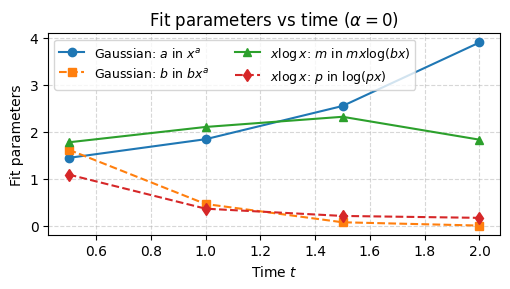

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Load Mathematica-style data
# ============================================================
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0]
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# ============================================================
# Settings (ONLY alpha = 0)
# ============================================================
base_path = "src"
file_path = os.path.join(base_path, "N50b3varyalphanoKac0.txt")

step_size = 0.01
steps_per_unit = 1 / step_size

times = np.arange(0.5, 2.01, 0.5)  # 0.5, 1.0, 1.5, 2.0
n_fit = 7
threshold = 1e-14

raw_data = load_mathematica_data(file_path)
n_steps = raw_data.shape[0]

os.makedirs("plt", exist_ok=True)

# ============================================================
# Models (log-space) -- FIXED to match what you asked for
#   log y = logA - b * x**a
#   log y = logA - a * x * log(b*x)
# ============================================================
def log_gaussian(x, logA, a, b):
    return logA - b * (x ** a)

def log_xlogx(x, logA, a, b):
    return logA - a * x * np.log(b * x)

# ============================================================
# Storage
# ============================================================
profiles = []

logA_g, a_g, b_g = [], [], []
dlogA_g, da_g, db_g = [], [], []

logA_xl, a_xl, b_xl = [], [], []
dlogA_xl, da_xl, db_xl = [], [], []

# ============================================================
# Extract profiles + fits
# ============================================================
for t in times:
    t_idx = min(int(round(t * steps_per_unit)), n_steps - 1)
    profile = raw_data[t_idx, 3:]
    sites = np.arange(1, profile.size + 1)

    mask = profile > threshold
    x = sites[mask][:n_fit]
    y = profile[mask][:n_fit]

    if x.size < 3:
        print(f"Skipping t={t:.2f}: not enough positive points after threshold.")
        profiles.append((x, y))
        # append NaNs so plotting won't crash
        for arr in (logA_g, a_g, b_g, dlogA_g, da_g, db_g, logA_xl, a_xl, b_xl, dlogA_xl, da_xl, db_xl):
            arr.append(np.nan)
        continue

    profiles.append((x, y))
    ly = np.log(y)

    # ---- Gaussian-like fit: logA - b x^a
    popt_g, pcov_g = curve_fit(
        log_gaussian, x, ly,
        p0=(np.log(y.max()), 2.0, 0.05),
        bounds=([-np.inf, 0.0, 0.0], [np.inf, np.inf, np.inf]),
        maxfev=20000
    )
    perr_g = np.sqrt(np.diag(pcov_g))
    logA_g.append(popt_g[0]); a_g.append(popt_g[1]); b_g.append(popt_g[2])
    dlogA_g.append(perr_g[0]); da_g.append(perr_g[1]); db_g.append(perr_g[2])

    # ---- xlogx fit: logA - a x log(bx)
    popt_xl, pcov_xl = curve_fit(
        log_xlogx, x, ly,
        p0=(np.log(y.max()), 0.05, 1.0),
        bounds=([-np.inf, 0.0, 0.0], [np.inf, np.inf, np.inf]),
        maxfev=20000
    )
    perr_xl = np.sqrt(np.diag(pcov_xl))
    logA_xl.append(popt_xl[0]); a_xl.append(popt_xl[1]); b_xl.append(popt_xl[2])
    dlogA_xl.append(perr_xl[0]); da_xl.append(perr_xl[1]); db_xl.append(perr_xl[2])

# ============================================================
# Plot 1: Gaussian-like fits (dashed lines for each time)
# ============================================================
plt.figure(figsize=(5, 2.8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(times)))

for (x, y), t, lgA, a, b, c in zip(profiles, times, logA_g, a_g, b_g, colors):
    if x.size == 0 or np.isnan(a) or np.isnan(b) or np.isnan(lgA):
        continue
    plt.semilogy(x, y, "o", color=c, markerfacecolor="none")
    x_dense = np.linspace(x.min(), x.max(), 300)
    plt.semilogy(x_dense, np.exp(log_gaussian(x_dense, lgA, a, b)),
                 "--", color=c, label=fr"$t={t:.1f}$")

plt.xlabel("Distance from crest")
plt.ylabel("Frobenius norm")
plt.title(r"Fits: $\exp[-b x^{a}]$  ($\alpha=0$)")
plt.legend(fontsize=9, ncol=2)
plt.grid(True, which="major", linestyle="--", alpha=0.4)
plt.tight_layout()
# plt.savefig("plt/Profile_GaussianLike_alpha0.svg", dpi=600)
plt.show()

# ============================================================
# Plot 2: x log x fits (dashed lines for each time)
# ============================================================
plt.figure(figsize=(5, 2.8))

for (x, y), t, lgA, a, b, c in zip(profiles, times, logA_xl, a_xl, b_xl, colors):
    if x.size == 0 or np.isnan(a) or np.isnan(b) or np.isnan(lgA):
        continue
    plt.semilogy(x, y, "o", color=c, markerfacecolor="none")
    x_dense = np.linspace(x.min(), x.max(), 300)
    plt.semilogy(x_dense, np.exp(log_xlogx(x_dense, lgA, a, b)),
                 "--", color=c, label=fr"$t={t:.1f}$")

plt.xlabel("Distance from crest")
plt.ylabel("Frobenius norm")
plt.title(r"Fits: $\exp[-m x\log(px)]$  ($\alpha=0$)")
plt.legend(fontsize=9, ncol=2)
plt.grid(True, which="major", linestyle="--", alpha=0.4)
plt.tight_layout()
# plt.savefig("plt/Profile_XlogX_alpha0.svg", dpi=600)
plt.show()

# ============================================================
# Plot 3: parameters vs time with error bars (a AND b for BOTH fits)
# ============================================================
plt.figure(figsize=(5.2, 3.0))

# Gaussian-like: a(t), b(t)
plt.plot(times, a_g, "o-", label=r"Gaussian: $a$ in $x^{a}$")
plt.plot(times, b_g, "s--", label=r"Gaussian: $b$ in $b x^{a}$")

# x log x: a(t), b(t)
plt.plot(times, a_xl, "^-", label=r"$x\log x$: $m$ in $m x\log(bx)$")
plt.plot(times, b_xl, "d--", label=r"$x\log x$: $p$ in $\log(px)$")


plt.xlabel("Time $t$")
plt.ylabel("Fit parameters")
plt.title(r"Fit parameters vs time ($\alpha=0$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
# plt.savefig("plt/Profile_FitParams_alpha0.svg", dpi=600)
plt.show()

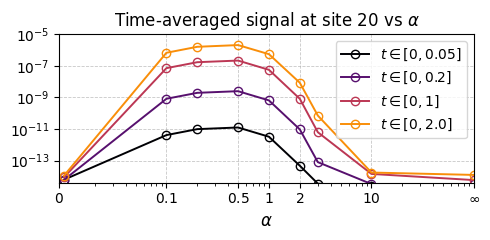

In [10]:
# -----------------------------
# Extract time-averaged signal at site 18 over windows [0,T] and plot vs alpha
# -----------------------------
site_index = 18  # site of interest (1-indexed)

T_values = [0.05, 0.2, 1, 2.0]  # averaging windows [0,T]
cmap = plt.cm.inferno
T_colors = [cmap(i / (len(T_values))) for i in range(len(T_values))]

plt.figure(figsize=(5, 2.5))

for T, t_color in zip(T_values, T_colors):
    alpha_vals = []
    signal_avg_at_site = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"N50b3varyalphanoKac{J}.txt")
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found, skipping α={J/10:.1f}.")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]

        # Convert T -> final index; average from index 0 ... t_end_idx
        t_end_idx = min(int(T * steps_per_unit), n_steps - 1)

        # profile columns start at 3:
        # Slice time range [0, t_end_idx] and pick your site component
        # raw_data shape: (time_steps, cols); profile cols: 3:
        profiles = raw_data[0:t_end_idx + 1, 3:]

        if site_index - 1 < profiles.shape[1]:
            series = profiles[:, site_index - 1]

            # --- Choose averaging definition ---
            avg_signal = float(np.mean(series))          # simple time average
            # avg_signal = float(np.trapz(series, dx=1/steps_per_unit) / (T if T > 0 else 1.0))  # integral/T
            # avg_signal = float(np.sqrt(np.mean(series**2)))  # RMS
            # avg_signal = float(np.max(series))               # max over [0,T]

            signal_avg_at_site.append(avg_signal)

            if J == 1000:
                alpha_vals.append(100)  # placeholder for ∞ on the axis
            else:
                alpha_vals.append(J / 10 if J != 0 else 0.01)

    # Plot curve for this averaging window
    plt.loglog(
        alpha_vals, signal_avg_at_site, 'o-', color=t_color,
        markerfacecolor='none', markeredgecolor=t_color, linewidth=1.4,
        label=fr"$t\in{{[0,{T}]}}$"
    )

# --- Axis formatting ---
plt.xlim(0.009, 100)
plt.ylim(4e-15, 1e-5)
plt.xlabel(r"$\alpha$", fontsize=12)
# plt.ylabel(r"Time-averaged Frobenius norm", fontsize=10)
plt.title(r"Time-averaged signal at site 20 vs $\alpha$", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=10, title_fontsize=10)

plt.xticks(
    [0.009, 0.1, 0.5, 1, 2, 10, 100],
    [r"$0$", r"$0.1$", r"$0.5$", r"$1$", r"$2$", r"$10$", r"$\infty$"]
)

plt.tight_layout()
plt.savefig(f"plt/AvgSignal_site{site_index}_vs_alpha.svg", dpi=600)
plt.show()


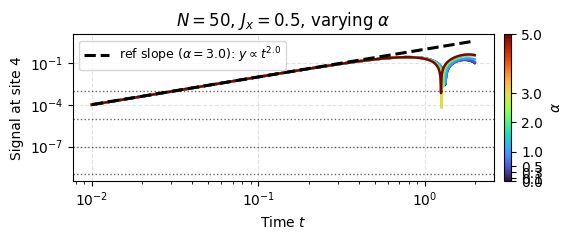

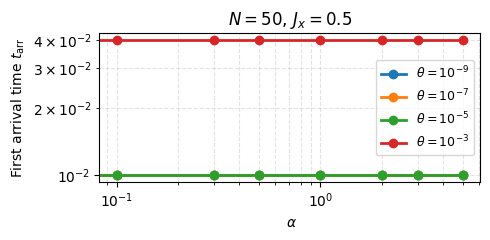

In [5]:
from matplotlib.colors import Normalize
import numpy as np
import os
import matplotlib.pyplot as plt


def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)


# -----------------------------
# Settings
# -----------------------------
# ⬇⬇⬇ 1000 REMOVED  100⬇⬇⬇
# alpha_tags = np.array([0, 1, 2, 5, 10, 20, 30])
alpha_tags = np.array([0, 1, 3, 5, 10, 20, 30,50]) #, 1000
base_path = "src"

N_system = 50
Jx_fixed = 0.5

site_of_interest = 3
tInterval = 0.01

# slope fit
t_fit_min = 1e-2
t_fit_max = 0.2
tag_ref = 30
anchor_t = 0.1

thresholds = [1e-9, 1e-7, 1e-5, 1e-3]

# -----------------------------
# Map tags → alpha
# -----------------------------
alpha_vals = alpha_tags / 10.0
norm = Normalize(vmin=alpha_vals.min(), vmax=alpha_vals.max())
cmap = plt.cm.turbo


# -----------------------------
# Load data (filenames unchanged)
# -----------------------------
series = {}
Tmin = None

for tag in alpha_tags:
    fn = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{tag}.txt")
    raw = load_mathematica_data(fn)

    if raw.size == 0:
        print(f"[WARN] Empty file: {fn}")
        continue

    y = raw[:, site_of_interest]
    series[tag] = y
    Tmin = len(y) if Tmin is None else min(Tmin, len(y))

t = np.arange(Tmin) * tInterval


# -----------------------------
# Fit slope on reference curve
# -----------------------------
t_line = y_line = None
p = np.nan

if tag_ref in series:
    y_ref = series[tag_ref][:Tmin]
    mask = (t >= t_fit_min) & (t <= t_fit_max) & (y_ref > 0)

    if np.sum(mask) >= 3:
        p, _ = np.polyfit(np.log(t[mask]), np.log(y_ref[mask]), 1)

        ti0 = int(round(anchor_t / tInterval))
        ti0 = np.clip(ti0, 0, Tmin - 1)
        C = y_ref[ti0] / (t[ti0] ** p)

        t_line = np.geomspace(t_fit_min, t[-1], 400)
        y_line = C * t_line ** p


# -----------------------------
# 1) Time traces vs t
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 2.5))

for tag, a in zip(alpha_tags, alpha_vals):
    y = series[tag][:Tmin]
    m = (t > 0) & (y > 0)
    ax.loglog(t[m], y[m], lw=1.8, color=cmap(norm(a)))

if t_line is not None:
    ax.loglog(
        t_line, y_line, "k--", lw=2.2,
        label=rf"ref slope ($\alpha={tag_ref/10:.1f}$): $y\propto t^{{{p:.1f}}}$"
    )

for th in thresholds:
    ax.axhline(th, color="k", lw=1.0, ls=":", alpha=0.6)

ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"Signal at site 4")
ax.set_title(rf"$N={N_system}$, $J_x={Jx_fixed}$, varying $\alpha$")
ax.grid(True, linestyle="--", alpha=0.35)

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\alpha$")
cbar.set_ticks(alpha_vals)
cbar.set_ticklabels([f"{a:.1f}" for a in alpha_vals])
cbar.ax.minorticks_off()

if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/JlongtimeArrVaryAlpha1.svg", dpi=600)
plt.show()


# -----------------------------
# 2) Arrival times vs alpha
# -----------------------------
arrival = {th: [] for th in thresholds}

for tag in alpha_tags:
    y = series[tag][:Tmin]
    for th in thresholds:
        idx = np.where(y >= th)[0]
        arrival[th].append(np.nan if len(idx) == 0 else idx[0] * tInterval)

fig, ax = plt.subplots(figsize=(5, 2.5))

for th in thresholds:
    tarr = np.array(arrival[th])
    m = np.isfinite(tarr) & (tarr > 0)
    ax.loglog(alpha_vals[m], tarr[m], "o-", lw=2, ms=6,
              label=rf"$\theta=10^{{{int(np.log10(th))}}}$")

ax.set_xlabel(r" $\alpha$")
ax.set_ylabel(r"First arrival time $t_{\mathrm{arr}}$")
ax.set_title(rf"$N={N_system}$, $J_x={Jx_fixed}$")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/JlongtimeArrVaryAlpha2.svg", dpi=600)
plt.show()


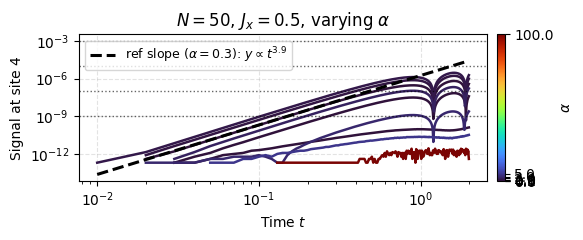

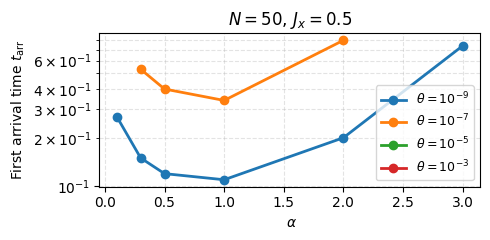

In [36]:
from matplotlib.colors import Normalize
import numpy as np
import os
import matplotlib.pyplot as plt


def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)


# -----------------------------
# Settings
# -----------------------------
# ⬇⬇⬇ 1000 REMOVED  100⬇⬇⬇
# alpha_tags = np.array([0, 1, 2, 5, 10, 20, 30])
alpha_tags = np.array([0, 1, 3, 5, 10, 20, 30,50, 1000])
base_path = "src"

N_system = 50
Jx_fixed = 0.5

site_of_interest = 19
tInterval = 0.01

# slope fit
t_fit_min = 1e-2
t_fit_max = 0.2
tag_ref = 3
anchor_t = 0.1

thresholds = [1e-9, 1e-7, 1e-5, 1e-3]

# -----------------------------
# Map tags → alpha
# -----------------------------
alpha_vals = alpha_tags / 10.0
norm = Normalize(vmin=alpha_vals.min(), vmax=alpha_vals.max())
cmap = plt.cm.turbo


# -----------------------------
# Load data (filenames unchanged)
# -----------------------------
series = {}
Tmin = None

for tag in alpha_tags:
    fn = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{tag}.txt")
    raw = load_mathematica_data(fn)

    if raw.size == 0:
        print(f"[WARN] Empty file: {fn}")
        continue

    y = raw[:, site_of_interest]
    series[tag] = y
    Tmin = len(y) if Tmin is None else min(Tmin, len(y))

t = np.arange(Tmin) * tInterval


# -----------------------------
# Fit slope on reference curve
# -----------------------------
t_line = y_line = None
p = np.nan

if tag_ref in series:
    y_ref = series[tag_ref][:Tmin]
    mask = (t >= t_fit_min) & (t <= t_fit_max) & (y_ref > 0)

    if np.sum(mask) >= 3:
        p, _ = np.polyfit(np.log(t[mask]), np.log(y_ref[mask]), 1)

        ti0 = int(round(anchor_t / tInterval))
        ti0 = np.clip(ti0, 0, Tmin - 1)
        C = y_ref[ti0] / (t[ti0] ** p)

        t_line = np.geomspace(t_fit_min, t[-1], 400)
        y_line = C * t_line ** p


# -----------------------------
# 1) Time traces vs t
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 2.5))

for tag, a in zip(alpha_tags, alpha_vals):
    y = series[tag][:Tmin]
    m = (t > 0) & (y > 0)
    ax.loglog(t[m], y[m], lw=1.8, color=cmap(norm(a)))

if t_line is not None:
    ax.loglog(
        t_line, y_line, "k--", lw=2.2,
        label=rf"ref slope ($\alpha={tag_ref/10:.1f}$): $y\propto t^{{{p:.1f}}}$"
    )

for th in thresholds:
    ax.axhline(th, color="k", lw=1.0, ls=":", alpha=0.6)

ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"Signal at site 4")
ax.set_title(rf"$N={N_system}$, $J_x={Jx_fixed}$, varying $\alpha$")
ax.grid(True, linestyle="--", alpha=0.35)

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\alpha$")
cbar.set_ticks(alpha_vals)
cbar.set_ticklabels([f"{a:.1f}" for a in alpha_vals])
cbar.ax.minorticks_off()

if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/JlongtimeArrVaryAlpha1.svg", dpi=600)
plt.show()


# -----------------------------
# 2) Arrival times vs alpha
# -----------------------------
arrival = {th: [] for th in thresholds}

for tag in alpha_tags:
    y = series[tag][:Tmin]
    for th in thresholds:
        idx = np.where(y >= th)[0]
        arrival[th].append(np.nan if len(idx) == 0 else idx[0] * tInterval)

fig, ax = plt.subplots(figsize=(5, 2.5))

for th in thresholds:
    tarr = np.array(arrival[th])
    m = np.isfinite(tarr) & (tarr > 0)
    ax.semilogy(alpha_vals[m], tarr[m], "o-", lw=2, ms=6,
              label=rf"$\theta=10^{{{int(np.log10(th))}}}$")

ax.set_xlabel(r" $\alpha$")
ax.set_ylabel(r"First arrival time $t_{\mathrm{arr}}$")
ax.set_title(rf"$N={N_system}$, $J_x={Jx_fixed}$")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig("plt/JlongtimeArrVaryAlpha2.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


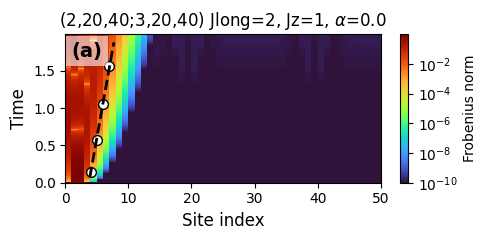

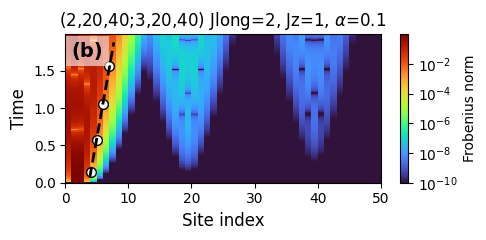

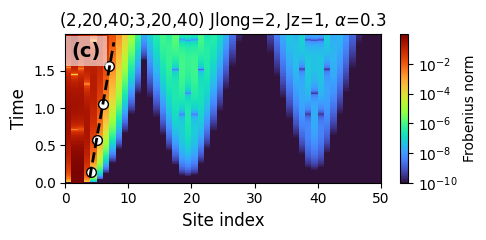

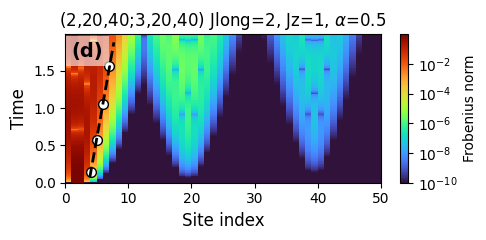

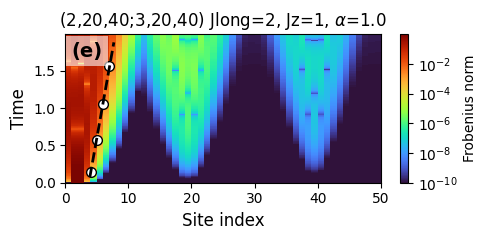

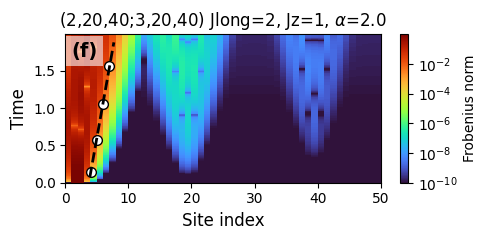

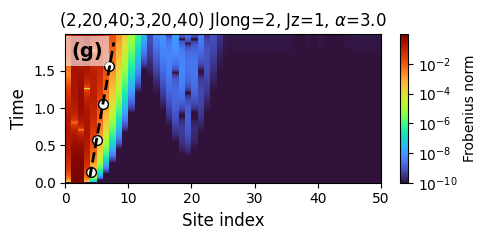

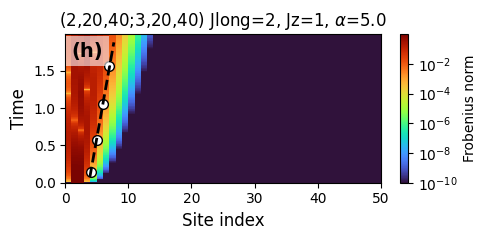

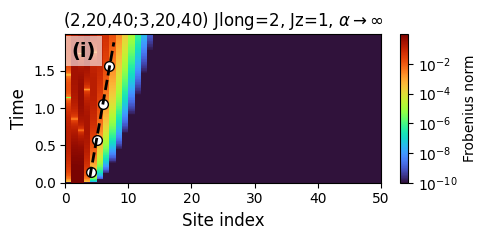

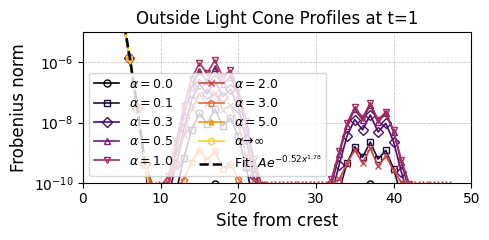

In [46]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([0, 1, 3, 5, 10, 20, 30,50, 1000])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)
    plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha$={J/10:.1f}", fontsize=12)
    if J == 1000:
         plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0,9)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-10, 1e-5)
plt.xlim(0, 50)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryAlpha.svg", dpi=600)
plt.show()



In [15]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
import imageio.v2 as imageio

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)


# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([0, 1, 3, 5, 10, 20, 30, 50, 1000])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

arrivals = [(4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)]
x_points = np.array([a[0] for a in arrivals])
y_points = np.array([a[1] for a in arrivals])

# Linear fit
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")


# -----------------------------
# Generate heatmaps (one per alpha)
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    # Overlay arrival points and fit
    plt.plot(x_points, y_points, 'wo', markersize=7,
             markeredgecolor="k", label="First arrivals")
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")

    plt.text(
        0.02, 0.95, label, transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold", va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)

    if J == 1000:
        plt.title(r"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    else:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha={J/10:.1f}$", fontsize=12)

    plt.tight_layout()

    # Save as PNG (important for GIF)
    plt.savefig(f"plt/Heatmap_alpha{J}.png", dpi=200)
    plt.close()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(5, 2.5))
cmap = plt.cm.inferno
colors = [cmap(i / 9) for i in range(0, 9)]
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h"]

all_x_fit, all_y_fit = [], []

for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # collect fit points
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    if J == 1000:
        label = r"$\alpha \to \infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )


# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

plt.ylim(1e-10, 1e-5)
plt.xlim(0, 50)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.savefig("plt/Profiles_VaryAlpha.png", dpi=200)
plt.close()


# -----------------------------
# Create GIF from saved PNG frames
# -----------------------------
frames = []
for J in Jlong_values:
    filename = f"plt/Heatmap_alpha{J}.png"
    if os.path.exists(filename):
        frames.append(imageio.imread(filename))

imageio.mimsave("plt/Heatmap_alpha_sweep.gif", frames, duration=1)
print("GIF saved to plt/Heatmap_alpha_sweep.gif")


Fit slope = 0.475, intercept = -1.775
GIF saved to plt/Heatmap_alpha_sweep.gif


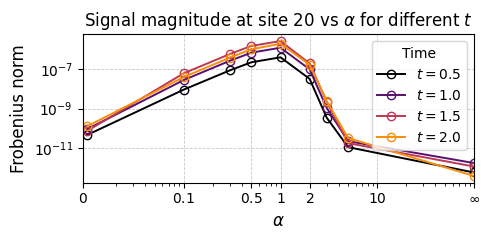

In [42]:
# -----------------------------
# Extract signal at site 17 for several times and plot vs alpha
# -----------------------------
site_index = 17  # site of interest (1-indexed)
time_values = [0.5, 1.0, 1.5, 2.0]  # times to compare

# Use a smooth color gradient for different times
import matplotlib.cm as cm
cmap = plt.cm.inferno
time_colors = [cmap(i / 4) for i in range(4)]

plt.figure(figsize=(5, 2.5))

for time_for_profile, t_color in zip(time_values, time_colors):
    alpha_vals = []
    signal_at_site = []

    for J in Jlong_values:  # reuse α color order if defined
        file_path = os.path.join(base_path, f"B0LFIMb2lcfarb3Varyalpha{J}.txt")
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found, skipping α={J/10:.1f}.")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
        profile = raw_data[t_index, 3:]

        if site_index-1 < len(profile):
            magnitude = profile[site_index - 1]
            signal_at_site.append(magnitude)
            if J == 1000:
                alpha_vals.append(100)   # placeholder for ∞ on the axis
            else:
                alpha_vals.append(J / 10 if J != 0 else 0.01)
    
    # Plot curve for this time
    plt.loglog(
        alpha_vals, signal_at_site, 'o-', color=t_color,
        markerfacecolor='none', markeredgecolor=t_color, linewidth=1.4,
        label=fr"$t={time_for_profile}$"
    )

# --- Axis formatting ---
plt.xlim(0.009, 100)
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Frobenius norm", fontsize=12)
plt.title(r"Signal magnitude at site 20 vs $\alpha$ for different $t$", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=10, title="Time", title_fontsize=10)

# --- Replace last tick label with ∞ ---
ticks = sorted(set(alpha_vals))
plt.xticks(
    [0.009, 0.1, 0.5, 1, 2, 10, 100],
    [r"$0$", r"$0.1$", r"$0.5$", r"$1$", r"$2$", r"$10$", r"$\infty$"]
)


plt.tight_layout()
plt.savefig(f"plt/Signal_site{site_index}_vs_alpha.svg", dpi=600)
plt.show()


Fit slope = 0.551, intercept = -2.294


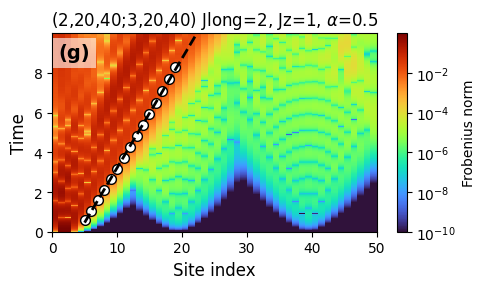

In [12]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([5])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (5, 0.57), (6, 1.06), (7, 1.58), (8, 2.10),
    (9, 2.63), (10, 3.17), (11, 3.72), (12, 4.26), (13, 4.80),
    (14, 5.37), (15, 5.91), (16, 6.49), (17, 7.08), (18, 7.68),
    (19, 8.30)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(5, 22, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Varyb{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label = {5:'(g)'}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)
    if J == 2:
        plt.title(fr"(2,20;3,20) Jlong=2, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==5:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==3:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha\to\infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_b{J}.pdf", dpi=600)
    plt.show()

Fit slope = 0.475, intercept = -1.775


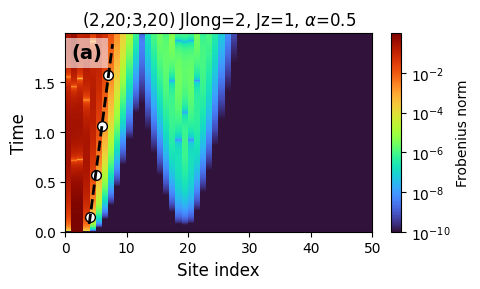

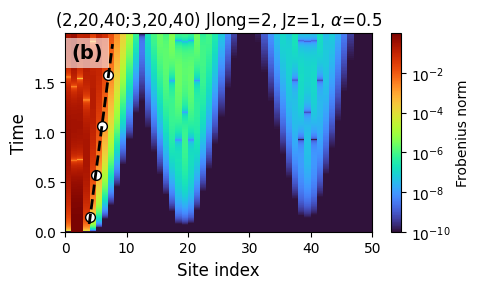

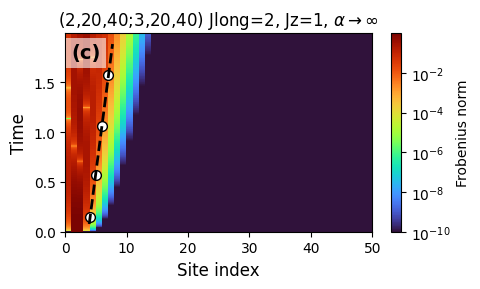

KeyError: np.int64(5)

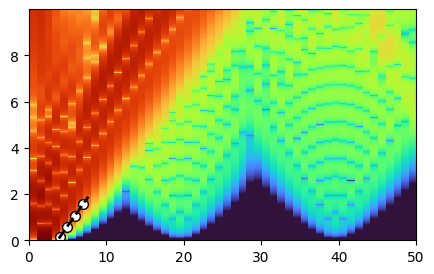

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([2,3,4,5])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Varyb{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label = {2: "(a)", 3: "(b)", 4: "(c)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)
    if J == 2:
        plt.title(fr"(2,20;3,20) Jlong=2, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==3:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==4:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha\to\infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_b{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)', 'd']
let=0
# for J, c in zip(Jlong_values, colors):
#     file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Varyb{J}.txt")
#     raw_data = load_mathematica_data(file_path)
#     n_steps = raw_data.shape[0]
#     t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
#     profile = raw_data[t_index, 3:]
#     sites = np.arange(1, profile.size + 1)
#     mask = profile > 1e-14
#     sites, profile = sites[mask], profile[mask]

#     # Collect first few points for a single global fit
#     n_fit =8
#     all_x_fit.extend(sites[:n_fit])
#     all_y_fit.extend(profile[:n_fit])
#     plt.semilogy(
#     sites, profile, "o",
#     markerfacecolor='none',     # open circles (no fill)
#     markeredgecolor=c,          # colored edges
#     markersize=5,
#     label=fr"$b$={J:.0f}"
#     )   
#     let+=1

# Define distinct markers
markers = ["x", "o", "^"]   # first = cross, rest = circles

for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Varyb{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    if J == 4:
        label = r"$b=3, \alpha\to\infty$"
    else:
        label = fr"$b$={J:.0f}, $\alpha=0.5$"

    plt.semilogy(
        sites, profile, m,
        markerfacecolor='none',     # open symbols
        markeredgecolor=c,
        markersize=6,
        linewidth=1.2,
        label=label
    )


# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlim(0, 50)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("plt/Profiles_Varyb.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


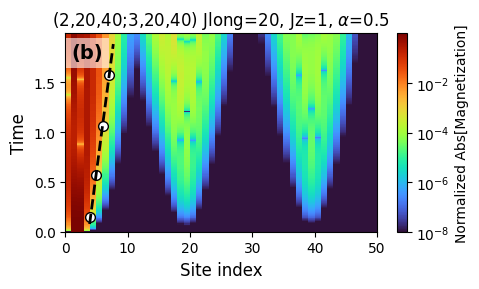

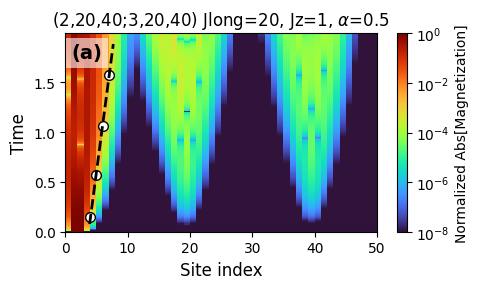

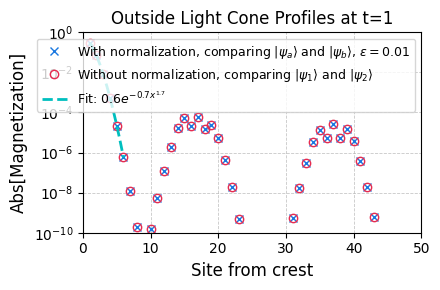

In [16]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,0])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Jlong20VarybPoles{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-8, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label = {0: "(a)", 1: "(b)", 4: "(c)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Normalized Abs[Magnetization]")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)
    if J == 0:
        plt.title(fr"(2,20,40;3,20,40) Jlong=20, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==1:
        plt.title(fr"(2,20,40;3,20,40) Jlong=20, Jz=1, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_bMag{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)']
let=0
# for J, c in zip(Jlong_values, colors):
#     file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Varyb{J}.txt")
#     raw_data = load_mathematica_data(file_path)
#     n_steps = raw_data.shape[0]
#     t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
#     profile = raw_data[t_index, 3:]
#     sites = np.arange(1, profile.size + 1)
#     mask = profile > 1e-14
#     sites, profile = sites[mask], profile[mask]

#     # Collect first few points for a single global fit
#     n_fit =8
#     all_x_fit.extend(sites[:n_fit])
#     all_y_fit.extend(profile[:n_fit])
#     plt.semilogy(
#     sites, profile, "o",
#     markerfacecolor='none',     # open circles (no fill)
#     markeredgecolor=c,          # colored edges
#     markersize=5,
#     label=fr"$b$={J:.0f}"
#     )   
#     let+=1

# Define distinct markers
markers = ["x", "o", "^"]   # first = cross, rest = circles

for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Jlong20VarybPoles{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 6
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    if J == 0:
        label = r"Without normalization, comparing $|\psi_1\rangle$ and $|\psi_2\rangle$"
    else:
        label = r"With normalization, comparing $|\psi_a\rangle$ and $|\psi_b\rangle$, $\epsilon=0.01$"

    plt.semilogy(
        sites, profile, m,
        markerfacecolor='none',     # open symbols
        markeredgecolor=c,
        markersize=6,
        linewidth=1.2,
        label=label
    )


# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlim(0, 50)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Abs[Magnetization]", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("plt/Profiles_Normalization.svg", dpi=600)
plt.show()


Fit slope = 0.475, intercept = -1.775


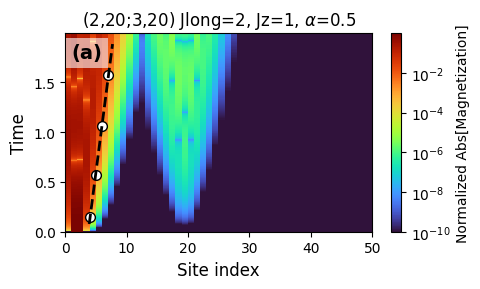

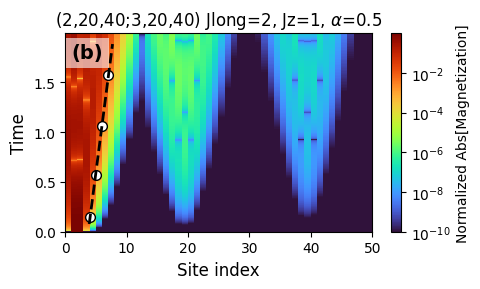

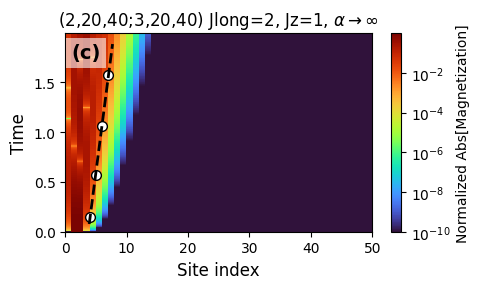

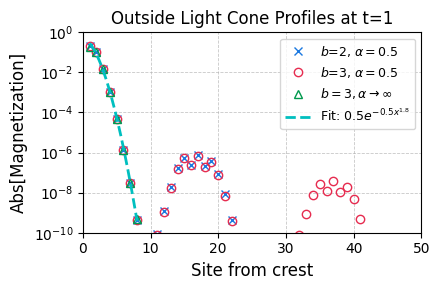

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([2,3,4])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05VarybMag{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label = {2: "(a)", 3: "(b)", 4: "(c)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Normalized Abs[Magnetization]")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 50)
    if J == 2:
        plt.title(fr"(2,20;3,20) Jlong=2, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==3:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha$=0.5", fontsize=12)
    if J==4:
        plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha\to\infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_bMag{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)']
let=0
# for J, c in zip(Jlong_values, colors):
#     file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Varyb{J}.txt")
#     raw_data = load_mathematica_data(file_path)
#     n_steps = raw_data.shape[0]
#     t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
#     profile = raw_data[t_index, 3:]
#     sites = np.arange(1, profile.size + 1)
#     mask = profile > 1e-14
#     sites, profile = sites[mask], profile[mask]

#     # Collect first few points for a single global fit
#     n_fit =8
#     all_x_fit.extend(sites[:n_fit])
#     all_y_fit.extend(profile[:n_fit])
#     plt.semilogy(
#     sites, profile, "o",
#     markerfacecolor='none',     # open circles (no fill)
#     markeredgecolor=c,          # colored edges
#     markersize=5,
#     label=fr"$b$={J:.0f}"
#     )   
#     let+=1

# Define distinct markers
markers = ["x", "o", "^"]   # first = cross, rest = circles

for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05VarybMag{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 8
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    if J == 4:
        label = r"$b=3, \alpha\to\infty$"
    else:
        label = fr"$b$={J:.0f}, $\alpha=0.5$"

    plt.semilogy(
        sites, profile, m,
        markerfacecolor='none',     # open symbols
        markeredgecolor=c,
        markersize=6,
        linewidth=1.2,
        label=label
    )


# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlim(0, 50)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Abs[Magnetization]", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("plt/Profiles_VarybMag.svg", dpi=600)
plt.show()


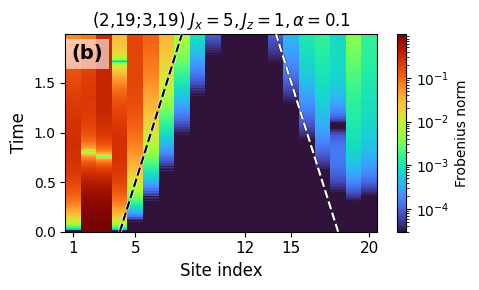

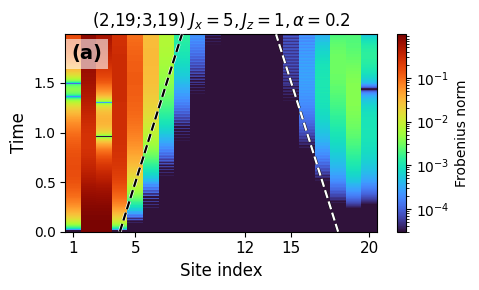

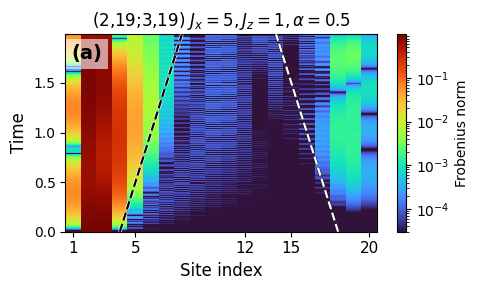

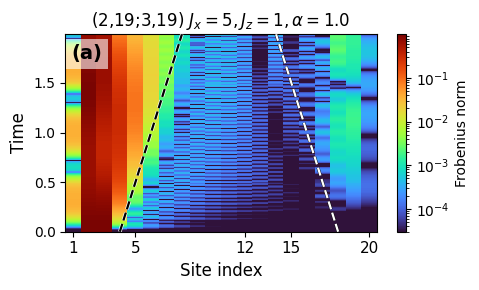

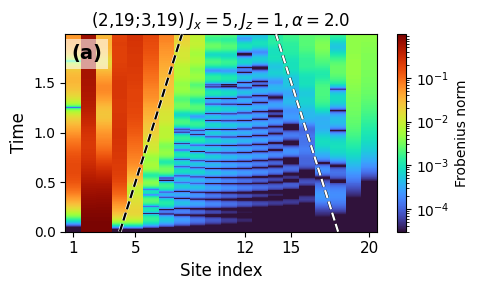

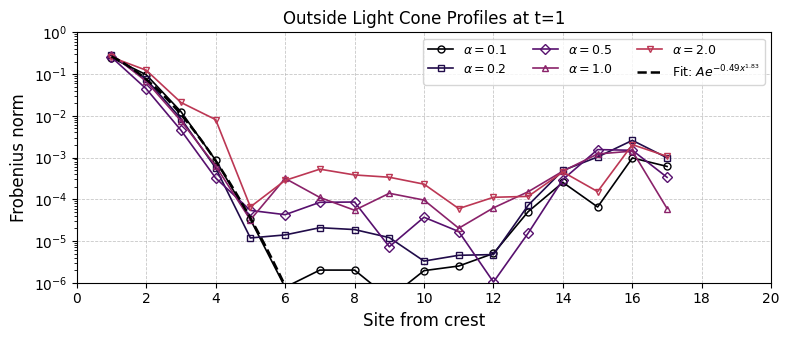

In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
import matplotlib.patheffects as pe

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,2,5,10,20 ]) #2 30, 100, 1000
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1
Jz = 1            # <-- set this to whatever you use in the simulation
x0_site = 3.5       # originating site index
use_site_centered_extent = True
n_sites=20
eps = 3e-5
os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=eps, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]

    # Choose velocity based on alpha regime
    v = None
    
    # -----------------------------
    # Velocity choice (copying your logic)
    # -----------------------------
    if J >= 100:
        v = 4 * Jz
    else:
        v = 2 * Jz

    # -----------------------------
    # Light-cone rays
    # -----------------------------
    if use_site_centered_extent:
        # x runs 0..Nsites, and "site i" centered at i-0.5
        x_min, x_max = 0.0, float(n_sites)
        extent = [x_min, x_max, t_min, t_max]
    else:
        # x runs 0..Nsites-1
        x_min, x_max = 0.0, float(n_sites - 1)
        extent = [x_min, x_max, t_min, t_max]

    # x0_site_right = 3.5  # site-centered origin (site 19 ~ 18.5 on imshow with -0.5 alignment)
    x0_site_left  = 17.5  # left-moving ray origin
    t_line_points = 400

    # -----------------------------
    # Panel label (optional)
    # -----------------------------
    label = "(b)" if J == 1 else "(a)"
    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    t_line = np.linspace(t_min, t_max, t_line_points)
    x0_site_right=3.5
    # Right-moving ray from x0_site_right
    x_line_right = x0_site_right + v * t_line
    mask_right = (x_line_right >= x_min) & (x_line_right <= x_max)

    plt.plot(
        x_line_right[mask_right], t_line[mask_right],
        linestyle="--",
        color="black",
        linewidth=1.6,
        zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),  # white outline
            pe.Normal()
        ]
    )

    # Left-moving ray from x0_site_left (white dashed)
    x_line_left = x0_site_left - v * t_line
    mask_left = (x_line_left >= x_min) & (x_line_left <= x_max)

    plt.plot(
        x_line_left[mask_left], t_line[mask_left],
        linestyle="--",
        color="white",
        linewidth=1.6,
        zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.2, foreground="black"),  # optional black outline so white stays visible
            pe.Normal()
        ]
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.1f}"

    plt.title(fr"(2,19;3,19) $J_{{x}}={5}, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15, 20])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20Jx5alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 8) for i in range(0,8)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 3:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-6, 1)
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2)) 
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N20Jx5Varyalpha2.svg", dpi=600)
plt.show()
# -----------------------------

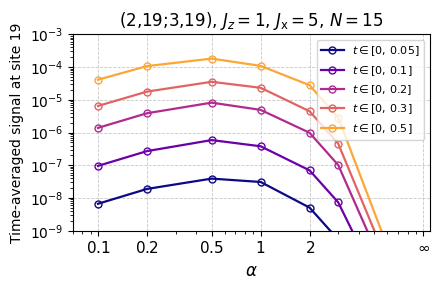

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.array([1,2,5,10,20,30,100,1000])
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 18  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3), (0.0, 0.5)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(1e-9, 1e-3)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 19", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}5$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx5Alpha2.svg", dpi=600)
plt.show()


Fit for t in [0.0, 0.5]: alpha^1.119913


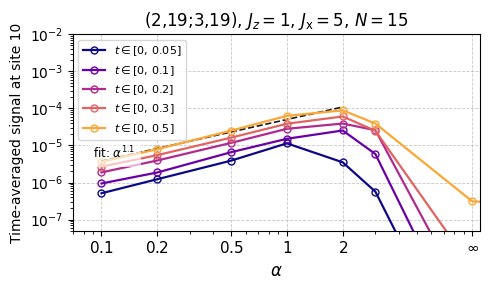

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(5, 3))

Jlong_values = np.array([1,2,5,10,20,30, 100, 1000]) #
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 9  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3),(0.0, 0.5)] #
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    if t_max==0.5:
        # -----------------------------
        # Power-law fit on alpha in [0.1, 2] for THIS time window
        # -----------------------------
        alpha_lo, alpha_hi = 0.1, 2.0

        # Only use points in the fit range, exclude the "infty" point (alpha=100) automatically
        fit_mask = (alphas >= alpha_lo) & (alphas <= alpha_hi) & np.isfinite(time_averages) & (time_averages > 0)

        if np.count_nonzero(fit_mask) >= 2:
            x = alphas[fit_mask]
            y = time_averages[fit_mask]

            # Fit: log(y) = m log(x) + b  => y = A x^m, A = exp(b)
            m_fit, b_fit = np.polyfit(np.log(x), np.log(y), 1)
            A_fit = np.exp(b_fit)

            # Draw fitted line (black dashed) for this window
            x_line = np.logspace(np.log10(alpha_lo), np.log10(alpha_hi), 200)
            y_line = A_fit * x_line**m_fit
            plt.plot(x_line, y_line, "k--", linewidth=1.2, alpha=0.9)

            # Put the equation near the right side of the fit range
            # (stagger text vertically by time-window index to avoid overlap)
            idx = time_windows.index((t_min, t_max))
            y_text = 0.85 - 0.12 * idx  # adjust spacing if needed
            eqn = fr"fit: $\alpha^{{{m_fit:.1f}}}$"
            plt.text(
                0.05, y_text, eqn,
                transform=plt.gca().transAxes,
                fontsize=8.5,
                color="k",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none")
            )

            print(f"Fit for t in [{t_min}, {t_max}]: alpha^{m_fit:.6f}")
        else:
            print(f"Not enough fit points in [{alpha_lo}, {alpha_hi}] for t in [{t_min}, {t_max}]")


    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 10", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}5$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx5Alpha3.svg", dpi=600)
plt.show()


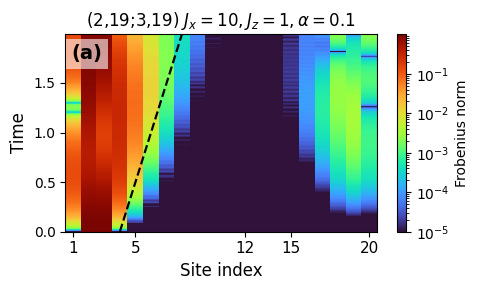

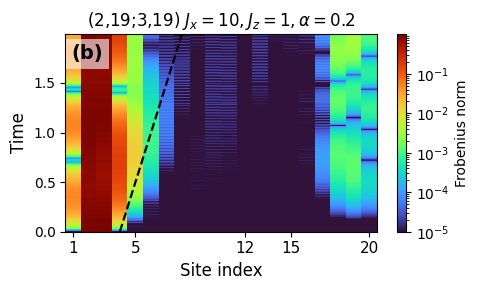

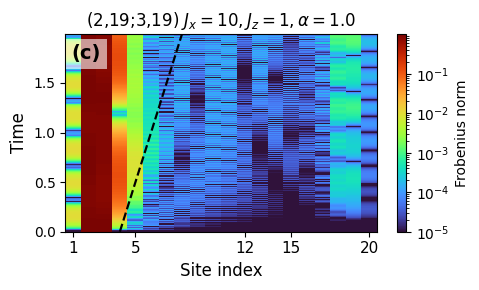

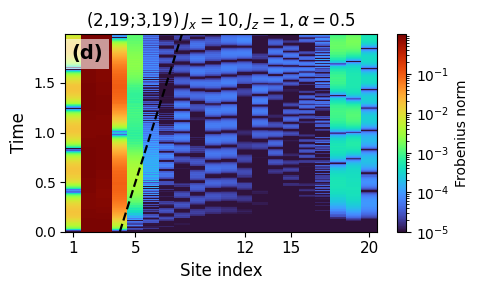

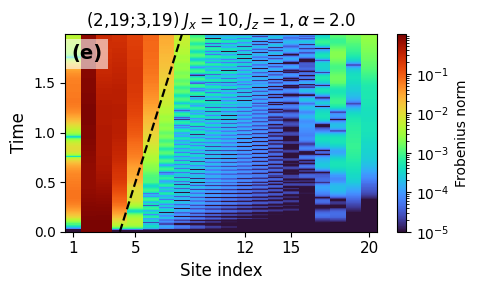

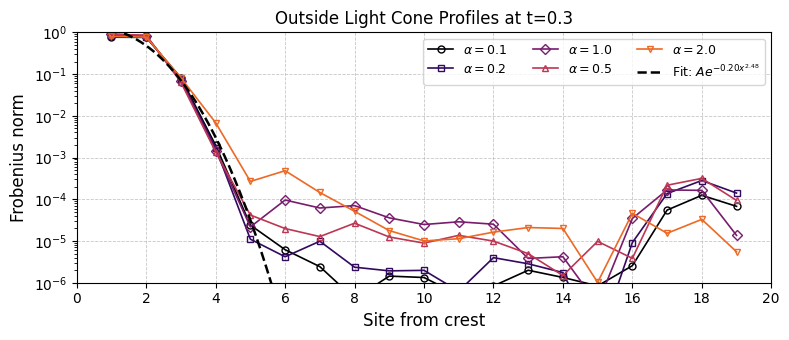

In [17]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,2, 10, 5,20]) #2
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 0.3
Jz = 1            # <-- set this to whatever you use in the simulation
x0_site = 3.5       # originating site index

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]

    # Choose velocity based on alpha regime
    v = None
    
    if J == 1000:   # alpha -> infinity panel
        v = 4 * Jz
    else:
        v = 2 * Jz

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    if v is not None:
        # time range on this panel
        t_line = np.linspace(t_min, t_max, 400)
        x_line = x0_site + v * t_line

        # keep only the part visible in the panel
        x_min, x_max = 0, raw_data.shape[1]
        mask = (x_line >= x_min) & (x_line <= x_max)
        plt.plot(x_line[mask], t_line[mask], "k--", linewidth=1.6, zorder=5)

    # # optional label near the start
    # plt.text(
    #     x0_site + 0.3, t_min + 0.05*(t_max - t_min),
    #     fr"$v={v}J_z$" if Jz == 1 else fr"$v={v}$",
    #     color="k", fontsize=10,
    #     bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    # )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.1f}"

    plt.title(fr"(2,19;3,19) $J_{{x}}={10}, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15, 20])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20Jx10alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 6) for i in range(0,6)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 1:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-6, 1)
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2)) 
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N20Jx10Varyalpha2.svg", dpi=600)
plt.show()
# -----------------------------

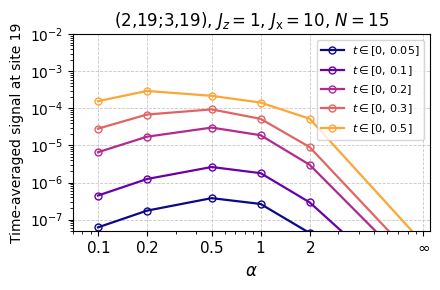

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.array([1,2,5,10,20,1000])
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 18  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3), (0.0, 0.5)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 19", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}10$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx10Alpha2.svg", dpi=600)
plt.show()


Fit for t in [0.0, 0.5]: alpha^1.102371


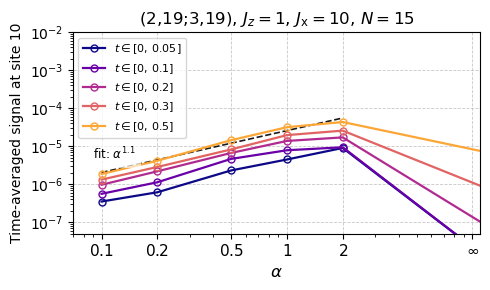

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(5, 3))

Jlong_values = np.array([1,2,5,10,20,1000]) #
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 9  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3),(0.0, 0.5)] #
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    if t_max==0.5:
        # -----------------------------
        # Power-law fit on alpha in [0.1, 2] for THIS time window
        # -----------------------------
        alpha_lo, alpha_hi = 0.1, 2.0

        # Only use points in the fit range, exclude the "infty" point (alpha=100) automatically
        fit_mask = (alphas >= alpha_lo) & (alphas <= alpha_hi) & np.isfinite(time_averages) & (time_averages > 0)

        if np.count_nonzero(fit_mask) >= 2:
            x = alphas[fit_mask]
            y = time_averages[fit_mask]

            # Fit: log(y) = m log(x) + b  => y = A x^m, A = exp(b)
            m_fit, b_fit = np.polyfit(np.log(x), np.log(y), 1)
            A_fit = np.exp(b_fit)

            # Draw fitted line (black dashed) for this window
            x_line = np.logspace(np.log10(alpha_lo), np.log10(alpha_hi), 200)
            y_line = A_fit * x_line**m_fit
            plt.plot(x_line, y_line, "k--", linewidth=1.2, alpha=0.9)

            # Put the equation near the right side of the fit range
            # (stagger text vertically by time-window index to avoid overlap)
            idx = time_windows.index((t_min, t_max))
            y_text = 0.85 - 0.12 * idx  # adjust spacing if needed
            eqn = fr"fit: $\alpha^{{{m_fit:.1f}}}$"
            plt.text(
                0.05, y_text, eqn,
                transform=plt.gca().transAxes,
                fontsize=8.5,
                color="k",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none")
            )

            print(f"Fit for t in [{t_min}, {t_max}]: alpha^{m_fit:.6f}")
        else:
            print(f"Not enough fit points in [{alpha_lo}, {alpha_hi}] for t in [{t_min}, {t_max}]")


    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 10", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}10$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx10Alpha3.svg", dpi=600)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(5, 3))

Jlong_values = np.array([1,2,5,10,20,1000]) #
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 9  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.5)] #(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3),
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    if t_max==0.5:
        # -----------------------------
        # Power-law fit on alpha in [0.1, 2] for THIS time window
        # -----------------------------
        alpha_lo, alpha_hi = 0.1, 2.0

        # Only use points in the fit range, exclude the "infty" point (alpha=100) automatically
        fit_mask = (alphas >= alpha_lo) & (alphas <= alpha_hi) & np.isfinite(time_averages) & (time_averages > 0)

        if np.count_nonzero(fit_mask) >= 2:
            x = alphas[fit_mask]
            y = time_averages[fit_mask]

            # Fit: log(y) = m log(x) + b  => y = A x^m, A = exp(b)
            m_fit, b_fit = np.polyfit(np.log(x), np.log(y), 1)
            A_fit = np.exp(b_fit)

            # Draw fitted line (black dashed) for this window
            x_line = np.logspace(np.log10(alpha_lo), np.log10(alpha_hi), 200)
            y_line = A_fit * x_line**m_fit
            plt.plot(x_line, y_line, "k--", linewidth=1.2, alpha=0.9)

            # Put the equation near the right side of the fit range
            # (stagger text vertically by time-window index to avoid overlap)
            idx = time_windows.index((t_min, t_max))
            y_text = 0.85 - 0.12 * idx  # adjust spacing if needed
            eqn = fr"fit: $\alpha^{{{m_fit:.1f}}}$"
            plt.text(
                0.05, y_text, eqn,
                transform=plt.gca().transAxes,
                fontsize=8.5,
                color="k",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none")
            )

            print(f"Fit for t in [{t_min}, {t_max}]: alpha^{m_fit:.6f}")
        else:
            print(f"Not enough fit points in [{alpha_lo}, {alpha_hi}] for t in [{t_min}, {t_max}]")


    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 10", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}10$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx10Alpha3.svg", dpi=600)
plt.show()


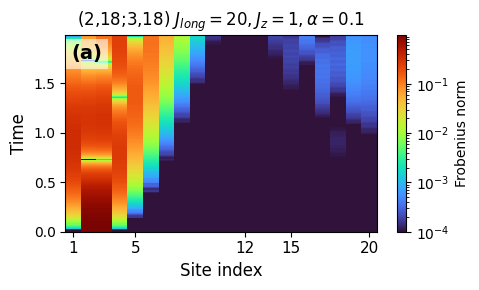

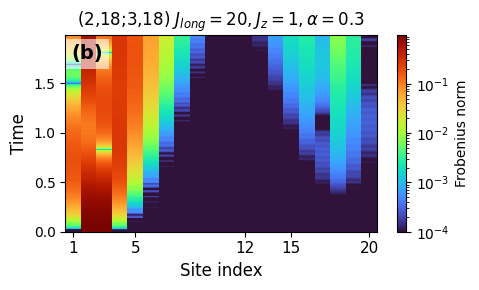

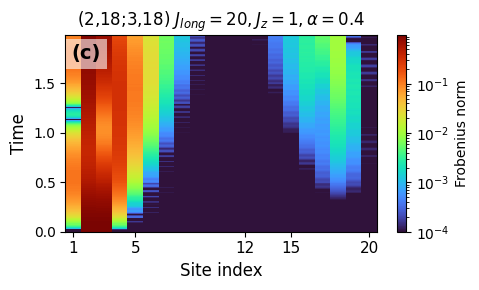

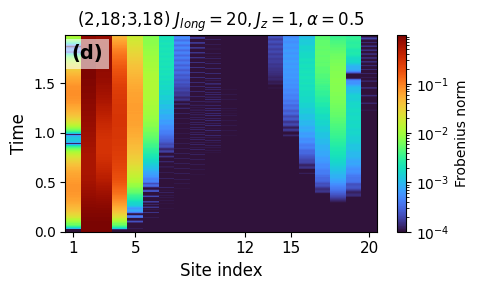

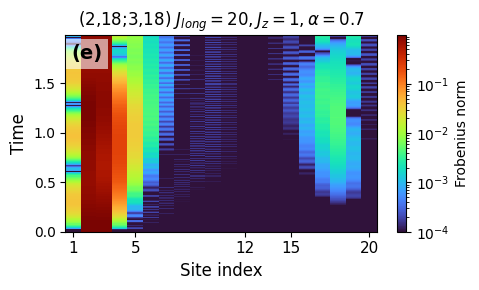

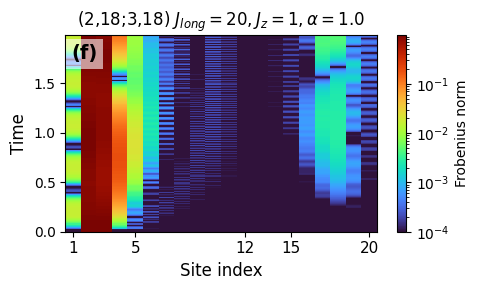

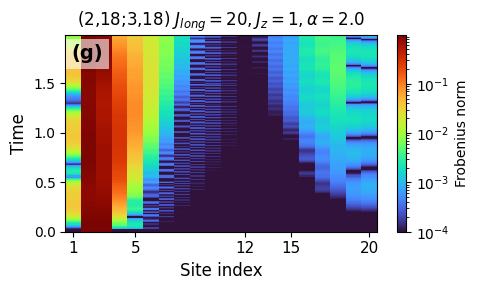

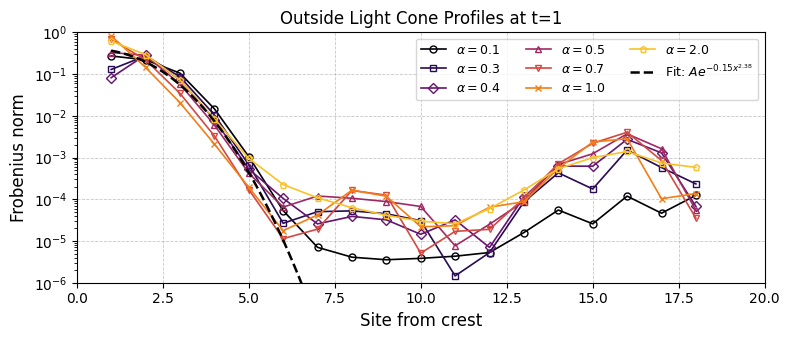

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,3,4,5,7,10,20]) #2
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.1f}"

    plt.title(fr"(2,18;3,18) $J_{{long}}=20, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15, 20])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 7) for i in range(0,7)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-6, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N20Varyalpha2.svg", dpi=600)
plt.show()

# -----------------------------

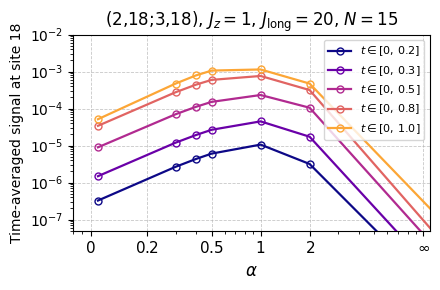

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.array([1,3,4,5,10,20,1000])
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 17  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.2),(0.0, 0.3), (0.0, 0.5), (0.0, 0.8), (0.0, 1.0)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.09, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 18", fontsize=10)
plt.title(r"(2,18;3,18), $J_z{=}1$, $J_{\mathrm{long}}{=}20$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Alpha2.svg", dpi=600)
plt.show()


Fit for t in [0.0, 0.5]: alpha^-0.029992


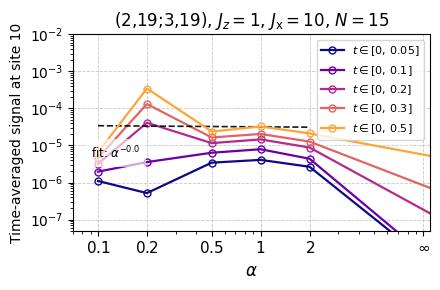

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.array([1,2,5,10,20,1000])
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 10  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3), (0.0, 0.5)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    if t_max==0.5:
        # -----------------------------
        # Power-law fit on alpha in [0.1, 2] for THIS time window
        # -----------------------------
        alpha_lo, alpha_hi = 0.1, 2.0

        # Only use points in the fit range, exclude the "infty" point (alpha=100) automatically
        fit_mask = (alphas >= alpha_lo) & (alphas <= alpha_hi) & np.isfinite(time_averages) & (time_averages > 0)

        if np.count_nonzero(fit_mask) >= 2:
            x = alphas[fit_mask]
            y = time_averages[fit_mask]

            # Fit: log(y) = m log(x) + b  => y = A x^m, A = exp(b)
            m_fit, b_fit = np.polyfit(np.log(x), np.log(y), 1)
            A_fit = np.exp(b_fit)

            # Draw fitted line (black dashed) for this window
            x_line = np.logspace(np.log10(alpha_lo), np.log10(alpha_hi), 200)
            y_line = A_fit * x_line**m_fit
            plt.plot(x_line, y_line, "k--", linewidth=1.2, alpha=0.9)

            # Put the equation near the right side of the fit range
            # (stagger text vertically by time-window index to avoid overlap)
            idx = time_windows.index((t_min, t_max))
            y_text = 0.85 - 0.12 * idx  # adjust spacing if needed
            eqn = fr"fit: $\alpha^{{{m_fit:.1f}}}$"
            plt.text(
                0.05, y_text, eqn,
                transform=plt.gca().transAxes,
                fontsize=8.5,
                color="k",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none")
            )

            print(f"Fit for t in [{t_min}, {t_max}]: alpha^{m_fit:.6f}")
        else:
            print(f"Not enough fit points in [{alpha_lo}, {alpha_hi}] for t in [{t_min}, {t_max}]")


    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 10", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}10$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx10Alpha4.svg", dpi=600)
plt.show()


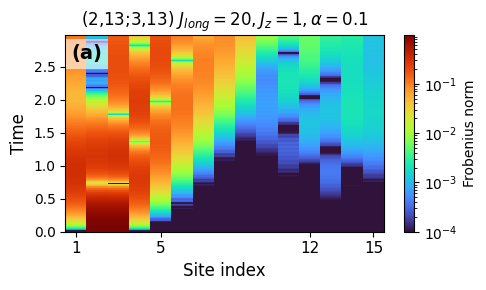

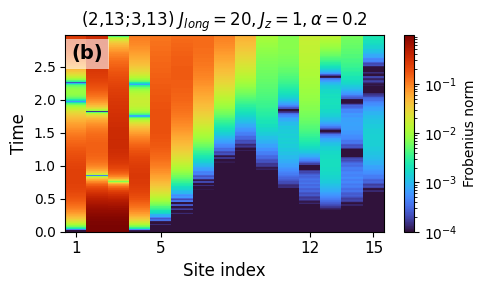

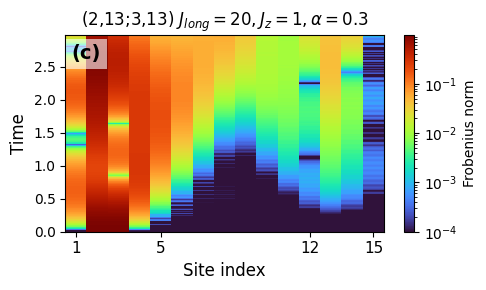

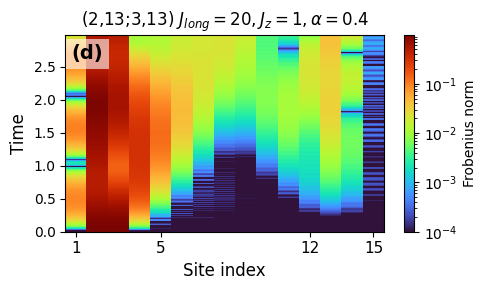

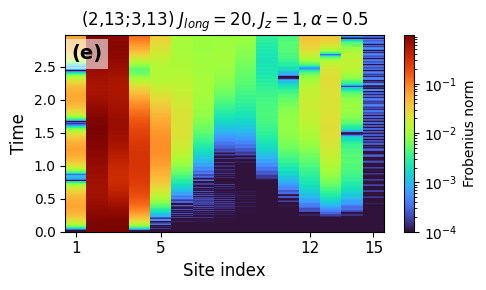

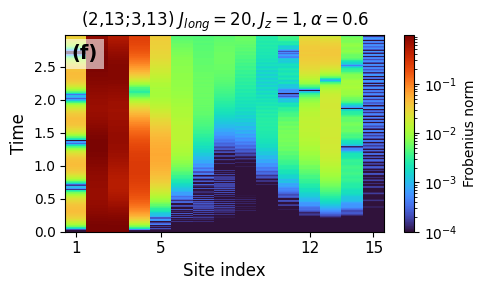

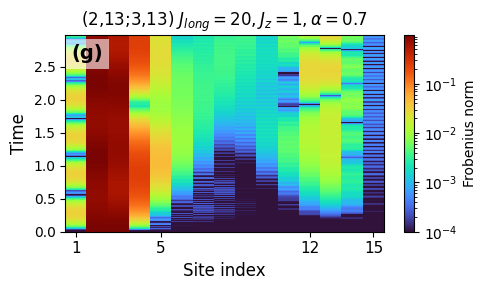

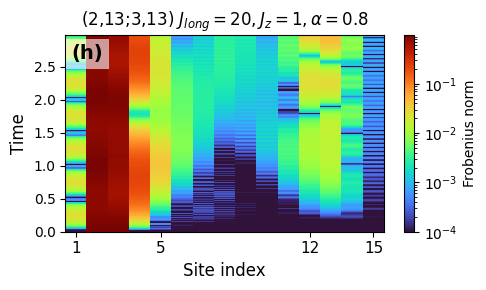

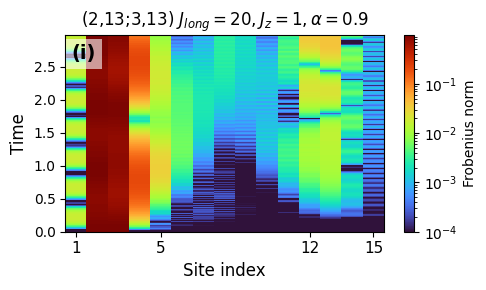

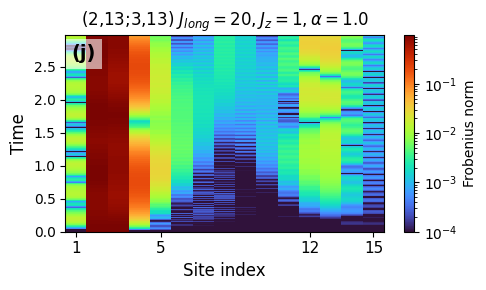

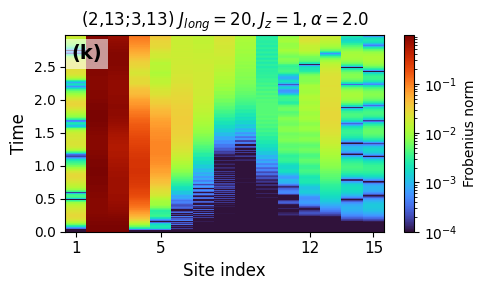

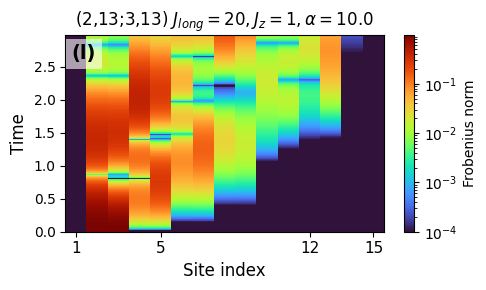

FileNotFoundError: [Errno 2] No such file or directory: 'src\\B0LFIMb2Varya02.txt'

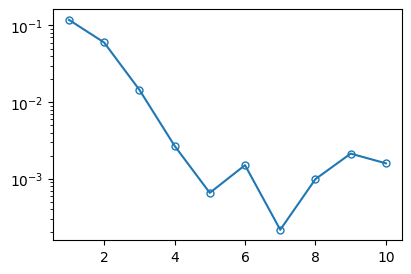

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,2,3,4,5,6,7,8,9,10,20,100]) #
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N15Jlong20Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.1f}"

    plt.title(fr"(2,13;3,13) $J_{{long}}=20, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N15alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.12, 0.47, 0.71),  # blue
    (1.00, 0.50, 0.05),  # orange
    (0.17, 0.63, 0.17),  # green
    (0.84, 0.15, 0.16),  # red
    (0.58, 0.40, 0.74),  # purple
    (0.55, 0.34, 0.29)   # brown
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
let=0
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 5:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit =5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    plt.semilogy(
    sites, profile, "o-",
    markerfacecolor='none',     # open circles (no fill)
    markeredgecolor=c,          # colored edges
    markersize=5,
    label = (
            fr"$\alpha={J/10:.1f}$" if J == 5 
            else fr"$\alpha=\infty$" if J == 1000 
            else fr"$\alpha={J/10:.0f}$"
        )
    )   
    let+=1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-9, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_N15Varyalpha2.svg", dpi=600)
plt.show()

# 



Fit slope = 0.475, intercept = -1.775


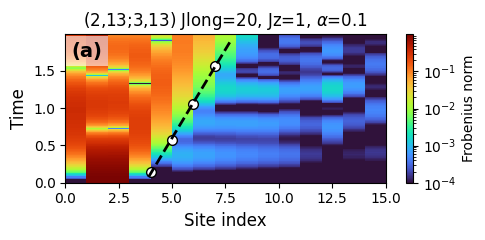

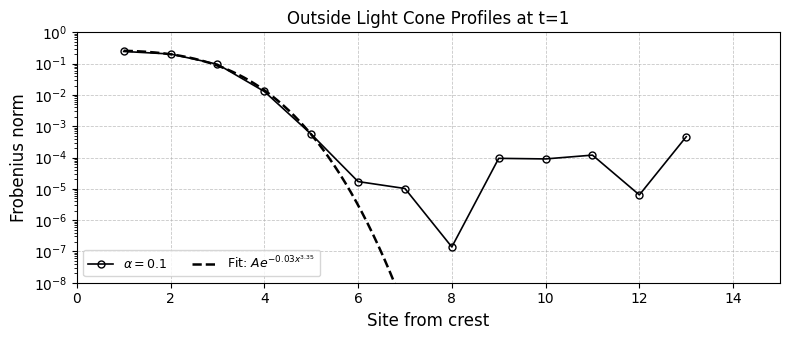

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
# Jlong_values = np.array([0, 1, 3, 5, 10, 20, 30,50, 1000])
Jlong_values = np.array([1]) #
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 15)
    plt.title(fr"(2,13;3,13) Jlong=20, Jz=1, $\alpha$={J/10:.1f}", fontsize=12)
    if J == 1000:
         plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 12) for i in range(0,12)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jlong20Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-8, 1)
plt.xlim(0, 15)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N20Jlong20Varyalpha2.svg", dpi=600)
plt.show()



Fit slope = 0.475, intercept = -1.775


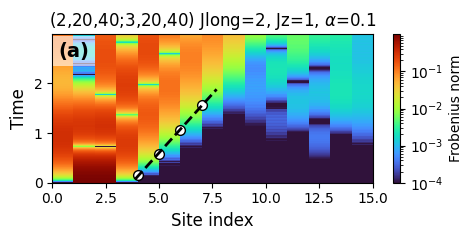

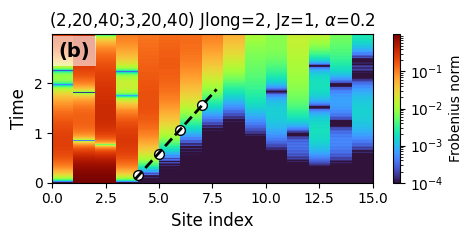

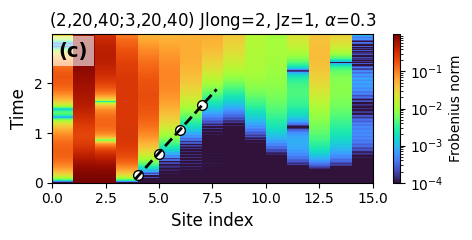

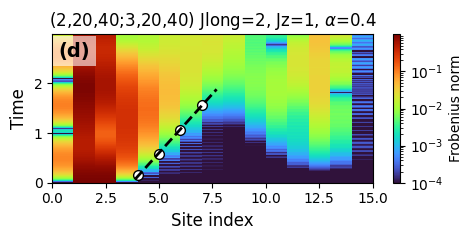

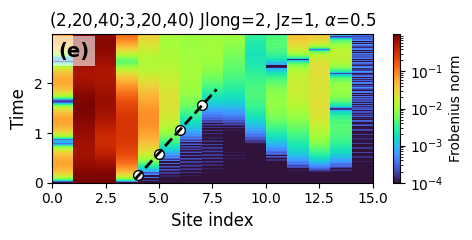

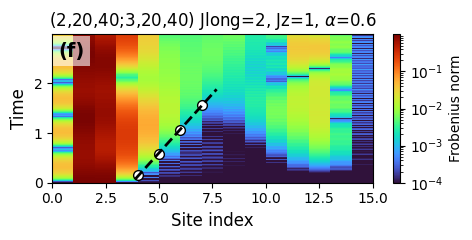

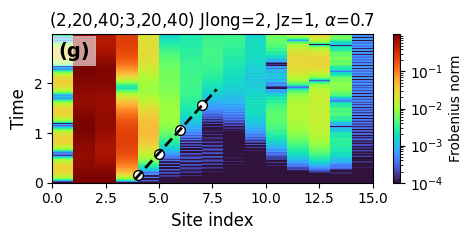

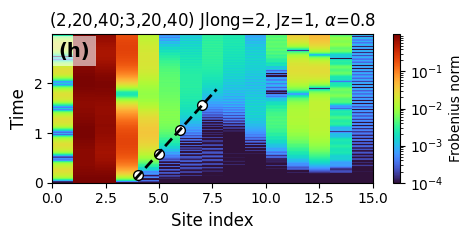

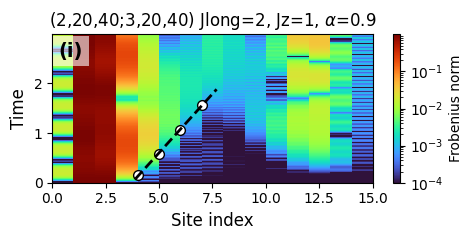

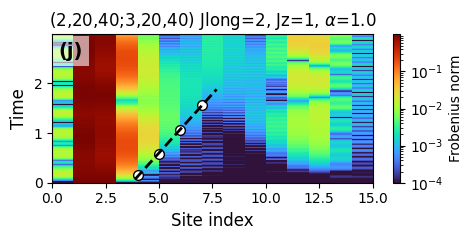

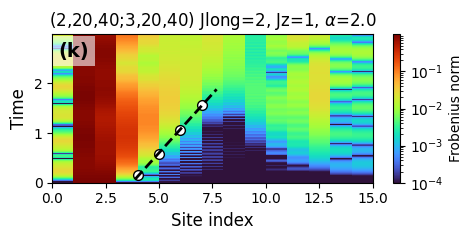

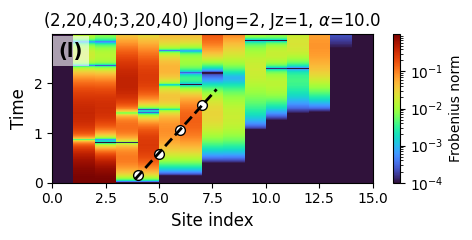

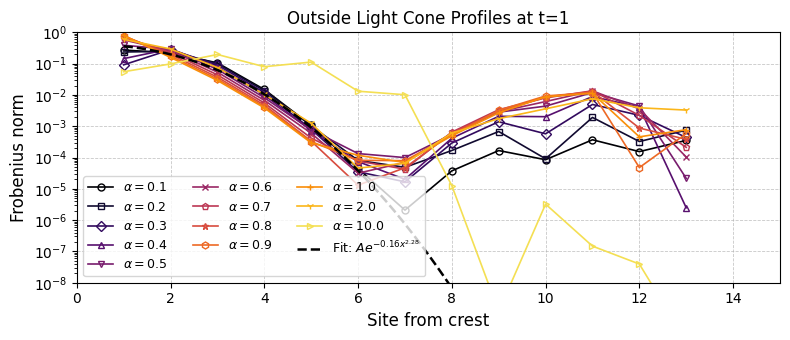

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
# Jlong_values = np.array([0, 1, 3, 5, 10, 20, 30,50, 1000])
Jlong_values = np.array([1,2,3,4,5,6,7,8,9,10,20,100]) #
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))
arrivals = [
    (4, 0.15), (5, 0.57), (6, 1.06), (7, 1.57)
]
x_points = np.array([a[0] for a in arrivals])   # site indices
y_points = np.array([a[1] for a in arrivals])   # times
# === Linear fit ===
fit_params = np.polyfit(x_points, y_points, 1)
fit_fn = np.poly1d(fit_params)
# x_fit = np.linspace(x_points.min(), x_points.max(), 200)
x_fit = np.linspace(3.9, 7.7, 200)
y_fit = fit_fn(x_fit)

slope, intercept = fit_params
print(f"Fit slope = {slope:.3f}, intercept = {intercept:.3f}")
# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N15Jlong20Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 2.5))
    im = plt.imshow(
        np.clip(raw_data, 1e-11, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-4, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )
    # Overlay first arrival points
    plt.plot(x_points, y_points, 'wo', markersize=7,
            markeredgecolor="k", label="First arrivals")

    # Overlay best-fit line
    plt.plot(x_fit, y_fit, 'k--', linewidth=2, label="Linear fit")

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict.get(J, "(?)")


    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.xlim(0, 15)
    plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha$={J/10:.1f}", fontsize=12)
    if J == 1000:
         plt.title(fr"(2,20,40;3,20,40) Jlong=2, Jz=1, $\alpha \to \infty$", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 12) for i in range(0,12)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N15Jlong20Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 2:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-8, 1)
plt.xlim(0, 15)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N15Varyalpha2.svg", dpi=600)
plt.show()



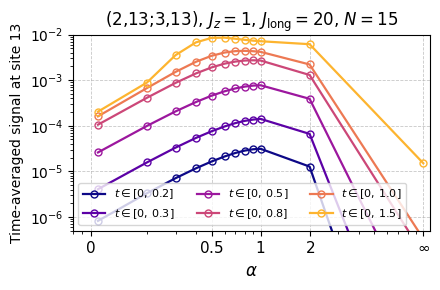

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 12  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.2),(0.0, 0.3), (0.0, 0.5), (0.0, 0.8), (0.0, 1.0)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N15Jlong20Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N15Jlong20Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-7, 1e-2)

# --- Custom X ticks ---
xticks = [0.09, 0.5, 1, 2, 10]
xlabels = [r"$0$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 13", fontsize=10)
plt.title(r"(2,13;3,13), $J_z{=}1$, $J_{\mathrm{long}}{=}20$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=3)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Alpha.svg", dpi=600)
plt.show()


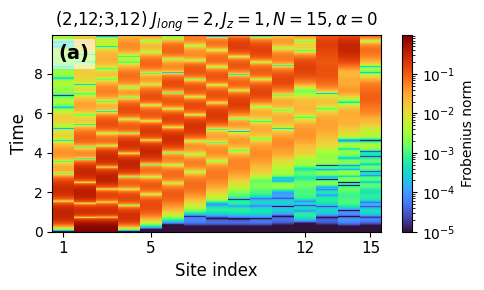

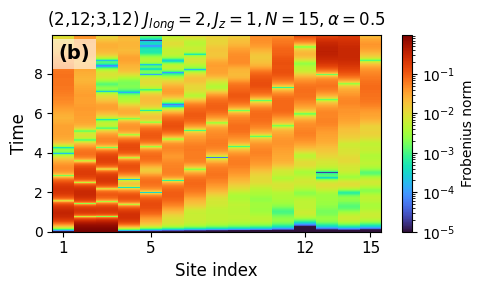

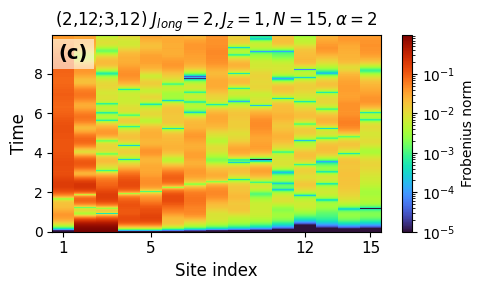

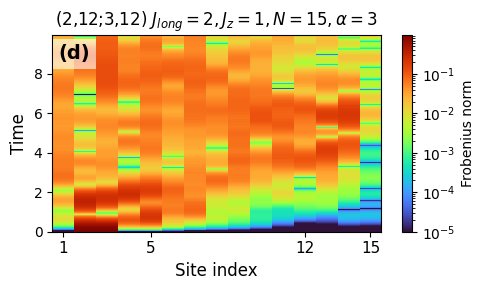

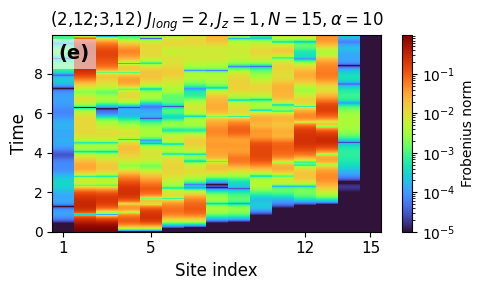

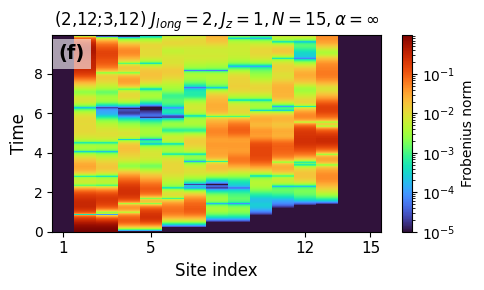

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

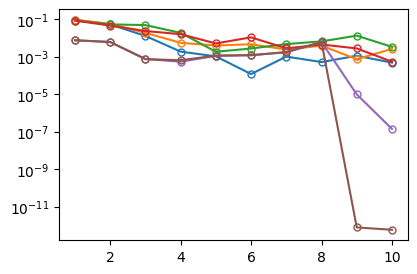

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([0, 5, 20, 30, 100, 1000 ])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label = {0: "(a)", 5: "(b)", 20: "(c)",30: "(d)", 100: "(e)", 1000: "(f)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.0f}"

    plt.title(fr"(2,12;3,12) $J_{{long}}=2, J_z=1, N=15, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.12, 0.47, 0.71),  # blue
    (1.00, 0.50, 0.05),  # orange
    (0.17, 0.63, 0.17),  # green
    (0.84, 0.15, 0.16),  # red
    (0.58, 0.40, 0.74),  # purple
    (0.55, 0.34, 0.29)   # brown
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
let=0
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 5:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit =5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    plt.semilogy(
    sites, profile, "o-",
    markerfacecolor='none',     # open circles (no fill)
    markeredgecolor=c,          # colored edges
    markersize=5,
    label = (
            fr"$\alpha={J/10:.1f}$" if J == 5 
            else fr"$\alpha=\infty$" if J == 1000 
            else fr"$\alpha={J/10:.0f}$"
        )
    )   
    let+=1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-9, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_Varyalpha2.svg", dpi=600)
plt.show()

# 



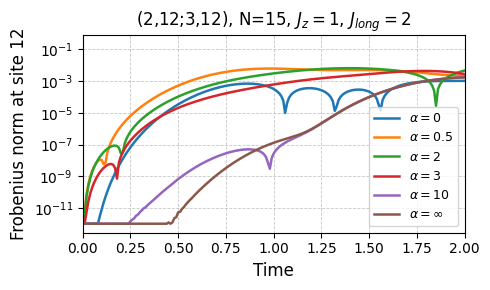

In [3]:
#-----------------------------
# Signal at site 14 vs time for different α
# -----------------------------
plt.figure(figsize=(5, 3))

# Distinct colors for each alpha
colors = [
    (0.12, 0.47, 0.71),  # blue
    (1.00, 0.50, 0.05),  # orange
    (0.17, 0.63, 0.17),  # green
    (0.84, 0.15, 0.16),  # red
    (0.58, 0.40, 0.74),  # purple
    (0.55, 0.34, 0.29)   # brown
]

site_index = 11   # <-- site of interest (1-based in your paper)
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit

    # Adjust for 0-based indexing in Python
    if site_index >= raw_data.shape[1]:
        print(f"⚠️ Site {site_index} out of range for {file_path}")
        continue

    signal = raw_data[:, site_index]

    # Clip for log plotting
    signal = np.clip(signal, 1e-12, None)

    plt.semilogy(
        time_axis, signal,
        '-', color=c, linewidth=1.8,
        label = (
            fr"$\alpha={J/10:.1f}$" if J == 5 
            else fr"$\alpha=\infty$" if J == 1000 
            else fr"$\alpha={J/10:.0f}$"
        )

    )

# -----------------------------
# Final formatting
# -----------------------------
plt.xlim(0, 2.0)   # show only up to t = 2.0 units
plt.xlabel("Time", fontsize=12)
plt.ylabel("Frobenius norm at site 12", fontsize=12)
plt.title(r"(2,12;3,12), N=15, $J_z=1$, $J_{{long}}=2$", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("plt/Site14_VaryAlpha.svg", dpi=600)
plt.show()

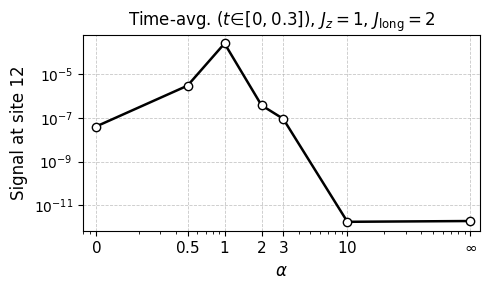

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------
# Time-averaged signal at site 12 vs α (for t in [0,0.5])
# -----------------------------
plt.figure(figsize=(5, 3))

site_index = 11   # 0-based index → site 12 in paper
t_min, t_max = 0.0, 0.3
time_averages = []
alphas = []
Jlong_values = np.array([5, 10, 20, 30, 100, 1000])  # skip 0 here (we'll handle separately)

# --- Compute α > 0 cases ---
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    mask = (time_axis >= t_min) & (time_axis <= t_max)
    if not np.any(mask):
        print(f"⚠️ No time points in range for {file_path}")
        continue

    signal = raw_data[mask, site_index]
    avg_value = np.mean(signal)
    time_averages.append(avg_value)
    alphas.append(J / 10)

alphas = np.array(alphas)
time_averages = np.array(time_averages)

# --- Add α = 0 case manually ---
J0 = 0
file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J0}.txt")
if os.path.exists(file_path):
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    mask = (time_axis >= t_min) & (time_axis <= t_max)
    avg0 = np.mean(raw_data[mask, site_index])
    # Insert α = 0 point (plotted at small value 0.09)
    alphas = np.insert(alphas, 0, 0.09)
    time_averages = np.insert(time_averages, 0, avg0)

# --- Plot ---
plt.plot(
    alphas, time_averages,
    'o-', linewidth=1.8, markersize=6,
    color='k', markerfacecolor='white'
)

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 120)

# --- Custom X ticks and labels ---
xticks = [0.09, 0.5, 1, 2, 3, 10, 100]
xlabels = [r"$0$", r"$0.5$", r"$1$", r"$2$", r"$3$", r"$10$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels and styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Signal at site 12", fontsize=12)
plt.title(r"Time-avg. $(t\!\in\![0,0.3])$, $J_z{=}1$, $J_{\mathrm{long}}{=}2$", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Alpha.svg", dpi=600)
plt.show()


In [21]:
time_averages

array([4.02727225e-08, 3.01633394e-06, 2.59789236e-04, 3.77934316e-07,
       9.12777227e-08, 1.71618208e-12, 1.86374214e-12])

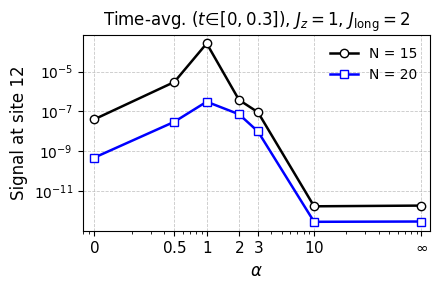

In [11]:
import numpy as np
import matplotlib.pyplot as plt

time_averages13 = np.array([4.02727225e-08, 3.01633394e-06, 2.59789236e-04, 3.77934316e-07,
       9.12777227e-08, 1.71618208e-12, 1.86374214e-12])
time_averages20 = np.array([4.79962050e-10, 3.01633394e-08, 3.07867219e-07, 7.20268948e-08, 9.87193259e-09,
       2.85609884e-13, 2.95196528e-13])

alphas = np.array([0.09, 0.5, 1, 2, 3, 10, 100])

plt.figure(figsize=(4.5, 3))

# --- Plot ---
plt.plot(
    alphas, time_averages13,
    'o-', linewidth=1.8, markersize=6,
    color='k', markerfacecolor='white',
    label='N = 15'
)
plt.plot(
    alphas, time_averages20,
    's-', linewidth=1.8, markersize=6,
    color='blue', markerfacecolor='white',
    label='N = 20'
)

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 120)

# --- Custom X ticks and labels ---
xticks = [0.09, 0.5, 1, 2, 3, 10, 100]
xlabels = [r"$0$", r"$0.5$", r"$1$", r"$2$", r"$3$", r"$10$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels and styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Signal at site 12", fontsize=12)
plt.title(r"Time-avg. $(t\!\in\![0,0.3])$, $J_z{=}1$, $J_{\mathrm{long}}{=}2$", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Alpha.svg", dpi=600)
plt.show()


In [ ]:
time_averagesN13

array([4.02727225e-08, 3.01633394e-06, 2.59789236e-04, 3.77934316e-07,
       9.12777227e-08, 1.71618208e-12, 1.86374214e-12])

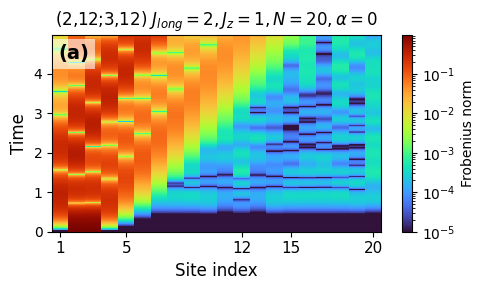

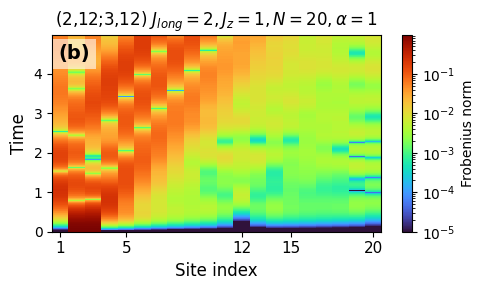

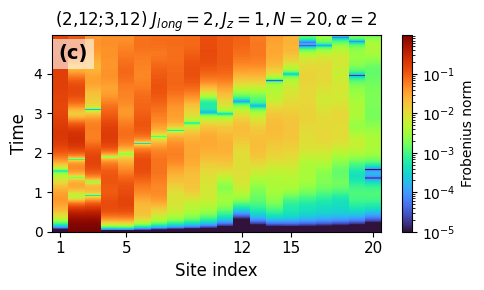

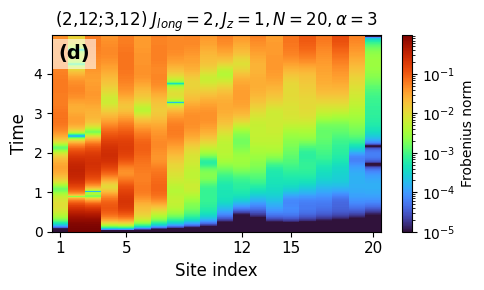

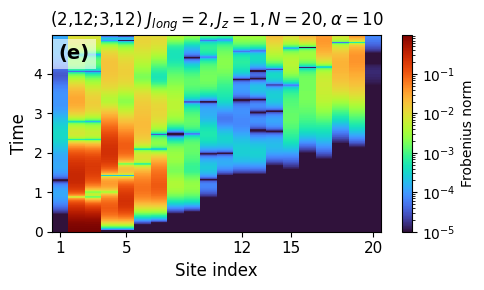

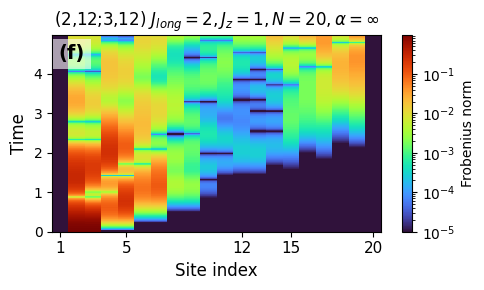

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

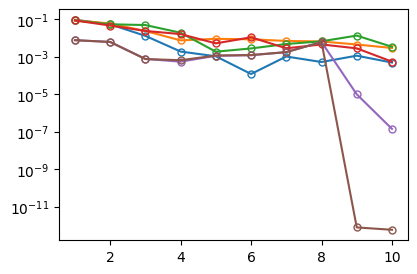

In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([0, 10, 20, 30, 100, 1000 ])
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N20B0LFIMb2Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label = {0: "(a)", 10: "(b)", 20: "(c)",30: "(d)", 100: "(e)", 1000: "(f)"}[J]

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.0f}"

    plt.title(fr"(2,12;3,12) $J_{{long}}=2, J_z=1, N=20, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15, 20])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 3))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.12, 0.47, 0.71),  # blue
    (1.00, 0.50, 0.05),  # orange
    (0.17, 0.63, 0.17),  # green
    (0.84, 0.15, 0.16),  # red
    (0.58, 0.40, 0.74),  # purple
    (0.55, 0.34, 0.29)   # brown
]


all_x_fit = []
all_y_fit = []

letters= ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
let=0
for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 5:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit =5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])
    plt.semilogy(
    sites, profile, "o-",
    markerfacecolor='none',     # open circles (no fill)
    markeredgecolor=c,          # colored edges
    markersize=5,
    label = (
            fr"$\alpha={J/10:.1f}$" if J == 5 
            else fr"$\alpha=\infty$" if J == 1000 
            else fr"$\alpha={J/10:.0f}$"
        )
    )   
    let+=1

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-9, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
# --- Add gridlines ---
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.savefig("plt/Profiles_N20Varyalpha2.svg", dpi=600)
plt.show()

# 



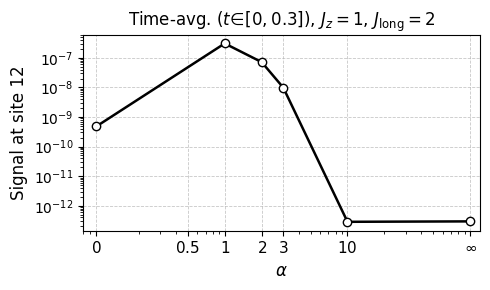

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------
# Time-averaged signal at site 12 vs α (for t in [0,0.5])
# -----------------------------
plt.figure(figsize=(5, 3))

site_index = 11   # 0-based index → site 12 in paper
t_min, t_max = 0.0, 0.2
time_averages = []
alphas = []
Jlong_values = np.array([10, 20, 30, 100, 1000])  # skip 0 here (we'll handle separately)

# --- Compute α > 0 cases ---
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N20B0LFIMb2Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    mask = (time_axis >= t_min) & (time_axis <= t_max)
    if not np.any(mask):
        print(f"⚠️ No time points in range for {file_path}")
        continue

    signal = raw_data[mask, site_index]
    avg_value = np.mean(signal)
    time_averages.append(avg_value)
    alphas.append(J / 10)

alphas = np.array(alphas)
time_averages = np.array(time_averages)

# --- Add α = 0 case manually ---
J0 = 0
file_path = os.path.join(base_path, f"N20B0LFIMb2Varya0{J0}.txt")
if os.path.exists(file_path):
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    mask = (time_axis >= t_min) & (time_axis <= t_max)
    avg0 = np.mean(raw_data[mask, site_index])
    # Insert α = 0 point (plotted at small value 0.09)
    alphas = np.insert(alphas, 0, 0.09)
    time_averages = np.insert(time_averages, 0, avg0)

# --- Plot ---
plt.plot(
    alphas, time_averages,
    'o-', linewidth=1.8, markersize=6,
    color='k', markerfacecolor='white'
)

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 120)

# --- Custom X ticks and labels ---
xticks = [0.09, 0.5, 1, 2, 3, 10, 100]
xlabels = [r"$0$", r"$0.5$", r"$1$", r"$2$", r"$3$", r"$10$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels and styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Signal at site 12", fontsize=12)
plt.title(r"Time-avg. $(t\!\in\![0,0.3])$, $J_z{=}1$, $J_{\mathrm{long}}{=}2$", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_N20Alpha.svg", dpi=600)
plt.show()


In [24]:
time_averages

array([4.79962050e-10, 3.07867219e-07, 7.20268948e-08, 9.87193259e-09,
       2.85609884e-13, 2.95196528e-13])

In [2]:
!pip install brokenaxes

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\shrey\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


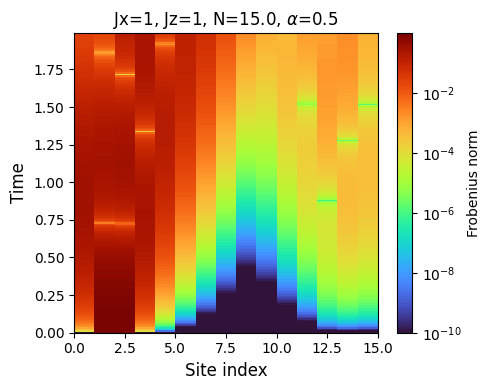

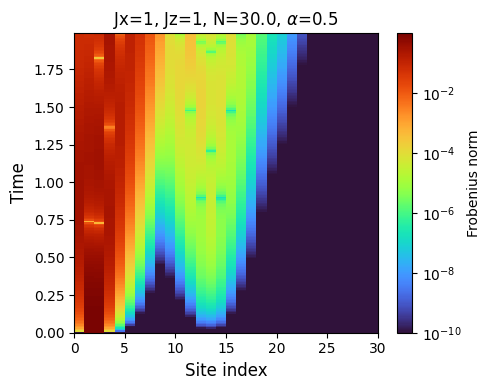

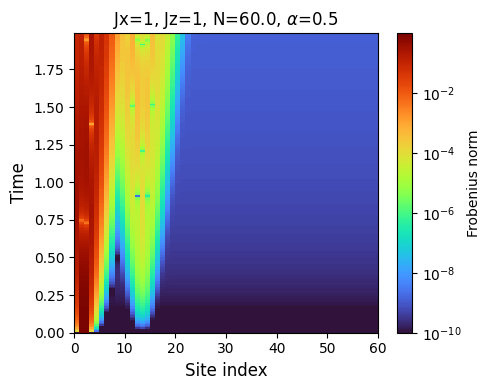

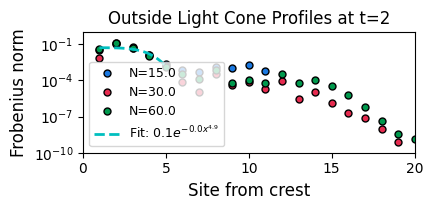

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = [15,30,60]
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 2

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
all_max = 0
for J in Jlong_values:
    data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05Jx1VaryNWscaling{J}.txt"))
    all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Jx1VaryNWscaling{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 4))
    im = plt.imshow(
    np.clip(raw_data, 1e-10, None),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    norm=mcolors.LogNorm(vmin=1e-10, vmax=all_max),
    interpolation="nearest",   # 👈 No smoothing
    extent=[0, raw_data.shape[1], t_min, t_max],
    rasterized=True            # 👈 Forces raster pixels in SVG/PDF
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"Jx=1, Jz=1, N={J:.1f}, $\alpha$=0.5", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N{J}.svg", dpi=600)
    plt.show()

# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 2.2))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30)   # greenish teal
]


all_x_fit = []
all_y_fit = []

for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Jx1VaryNWscaling{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 4:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    plt.semilogy(sites, profile, "o", color=c, markersize=5,
                 markeredgecolor="k", label=f"N={J:.1f}")

# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlim(0, 20)
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
# plt.savefig("plt/Profiles_VaryN.svg", dpi=600)
plt.show()


t = 0.10 → slope = -0.912
t = 0.50 → slope = -0.936
t = 2.00 → slope = -2.025


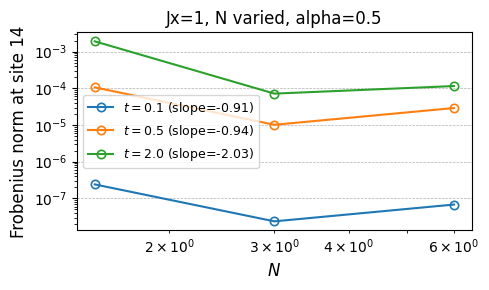

In [ ]:
# -----------------------------
# Plot: Site 14 value vs Jlong at fixed times (log-log)
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

Jlong_values = [15,30,60]
fixed_times = [0.1, 0.5, 2.0]
site_index = 13  # site 14 (0-based)
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(5, 3))

for t_fixed, c in zip(fixed_times, colors):
    values_at_t = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2lcfara05Jx1VaryNWscaling{J}.txt")
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit

        # Find the closest time index
        idx = np.argmin(np.abs(time_axis - t_fixed))
        val = raw_data[idx, site_index]
        values_at_t.append(val)
         # --- Log–log fit (y = A * N^slope) ---
        mask = (values_at_t > 0)
        slope, intercept = np.polyfit(np.log(Ns[mask]), np.log(values_at_t[mask]), 1)
        print(f"t = {t_fixed:>4.2f} → slope = {slope:.3f}")

        y_fit = np.exp(intercept) * Ns ** slope

        plt.loglog(Ns, values_at_t, "o-", color=c, markerfacecolor='none',
                markeredgewidth=1.2, label=fr"$t={t_fixed}$ (slope={slope:.2f})")
        plt.loglog(Ns, y_fit, "--", color=c, alpha=0.5)

    # Convert to arrays for fitting
    J_vals = np.array(Jlong_values) / 10.0
    y_vals = np.array(values_at_t)

    # Fit log(y) = m * log(J) + b  → slope = m
    mask = (y_vals > 1e-14)
    if np.sum(mask) >= 2:
        slope, intercept = np.polyfit(np.log(J_vals[mask]), np.log(y_vals[mask]), 1)
        print(f"t = {t_fixed:>4.2f} → slope = {slope:.3f}")
    else:
        slope = np.nan
        print(f"t = {t_fixed:>4.2f} → insufficient valid points")

    plt.loglog(
        J_vals, y_vals,
        "o-", color=c,
        markerfacecolor='none',
        markeredgewidth=1.2,
        label=fr"$t={t_fixed}$ (slope={slope:.2f})"
    )

plt.xlabel(r"$N$", fontsize=12)
plt.ylabel("Frobenius norm at site 14", fontsize=12)
plt.title("Jx=1, N varied, alpha=0.5", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, which="major", ls="--", lw=0.5)
plt.tight_layout()
# plt.savefig("plt/Site14_vs_Jlong_fixed_times.svg", dpi=600)
plt.show()


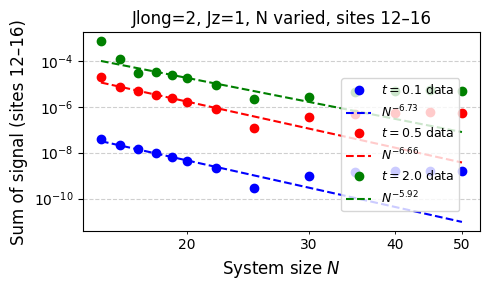

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter

# -----------------------------
# Helper: load Mathematica-style table
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            row = []
            for e in line.split(","):
                e = e.strip()
                if "+ 0." in e: e = e.split("+")[0].strip()
                if "*I" in e:   continue
                try:            row.append(float(e))
                except ValueError: pass
            if row: data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
N_values = np.array([15, 16, 17, 18, 19, 20, 22, 25, 30, 35, 40, 45, 50,100])
base_path = "src"
site_of_interest = 14
t_targets = [0.1, 0.5, 2.0]
tInterval = 0.01
steps_per_unit = 1 / tInterval

# -----------------------------
# Load data and extract signals
# -----------------------------
signals = {t: [] for t in t_targets}
for N in N_values:
    raw = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{N}.txt"))
    for t in t_targets:
        ti = min(int(t * steps_per_unit), raw.shape[0] - 1)
        # signals[t].append(raw[ti, site_of_interest])
        # Sum signal over sites 12–16 (inclusive)
        y_sum = np.mean(raw[ti, 14])
        signals[t].append(y_sum)

# -----------------------------
# Plot log–log
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))
colors = ["blue", "red", "green"]

for t, c in zip(t_targets, colors):
    x = N_values
    y = np.array(signals[t])
    mask = (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    # Take only the first few points for fitting (e.g., first 4)
    n_fit_points = 5
    x_fit_subset = x[3:n_fit_points]
    y_fit_subset = y[3:n_fit_points]

    # Fit log(y) = log(A) - alpha * log(x)
    slope, intercept = np.polyfit(np.log(x_fit_subset), np.log(y_fit_subset), 1)
    alpha = -slope
    A = np.exp(intercept)

    # Generate smooth fit curve
    x_fit = np.geomspace(x.min(), x.max(), 200)
    y_fit = A * x_fit ** (-alpha)

    ax.loglog(x, y, "o", color=c, label=fr"$t={t}$ data")
    ax.loglog(x_fit, y_fit, "--", color=c, label=fr"$N^{{-{alpha:.2f}}}$")


# -----------------------------
# Format axes
# -----------------------------
ax.set_xlabel(r"System size $N$", fontsize=12)
ax.set_ylabel(r"Sum of signal (sites 12–16)", fontsize=12)
ax.set_title(r"Jlong=2, Jz=1, N varied, sites 12–16", fontsize=12)
ax.grid(True, which="major", linestyle="--", alpha=0.6)

# X axis: plain numbers (no scientific)
from matplotlib.ticker import FuncFormatter

# Your formatter (keeps integers or one decimal for small x)
import matplotlib.ticker as mticker
ax.xaxis.set_minor_formatter(mticker.ScalarFormatter())


# Y axis: scientific notation
# ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
# ax.yaxis.get_major_formatter().set_powerlimits((-2, 2))

ax.legend(fontsize=9)
plt.legend(fontsize=9,  loc=(0.65, 0.1))
fig.tight_layout()
# plt.savefig("plt/Signal_vs_N_loglog_simple.svg", dpi=600)
plt.show()


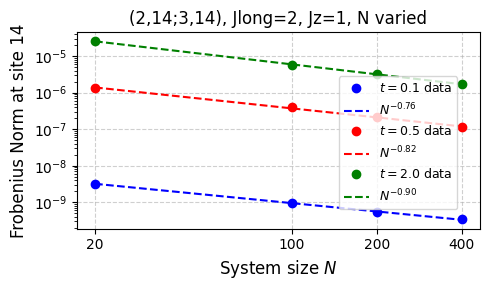

In [ ]:
sitesum100 = np.array([
    [0.1, 2.95795e-11], [0.2, 4.11164e-10], [0.3, 1.71338e-9],
    [0.4, 4.75062e-9], [0.5, 9.95777e-9], [0.6, 1.62452e-8],
    [0.7, 2.40116e-8], [0.8, 3.06272e-8], [0.9, 3.36132e-8],
    [1.0, 4.54229e-8], [1.1, 6.53094e-8], [1.2, 8.64266e-8],
    [1.3, 1.29877e-7], [1.4, 1.66198e-7], [1.5, 1.87698e-7],
    [1.6, 2.21240e-7], [1.7, 2.51343e-7], [1.8, 2.61102e-7],
    [1.9, 2.46807e-7], [2.0, 3.30038e-7], [2.1, 4.14858e-7],
    [2.2, 5.35527e-7], [2.3, 6.15428e-7], [2.4, 6.37870e-7],
    [2.5, 5.93794e-7], [2.6, 5.26324e-7], [2.7, 5.83286e-7],
    [2.8, 7.87361e-7], [2.9, 9.88648e-7], [3.0, 1.10528e-6]
])

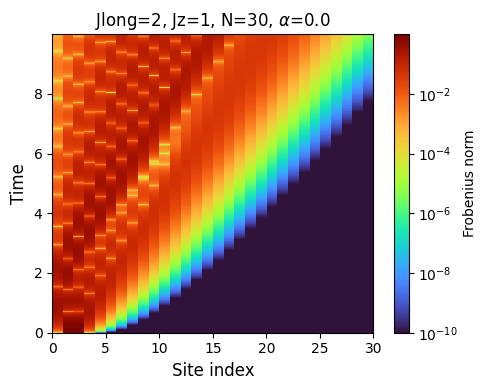

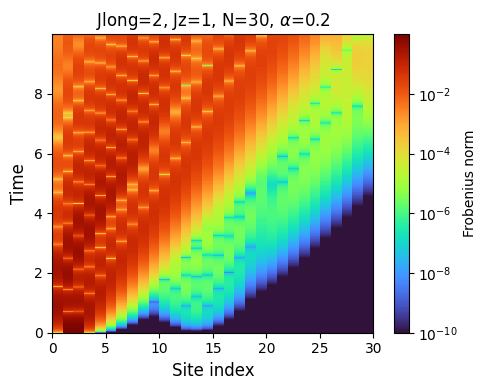

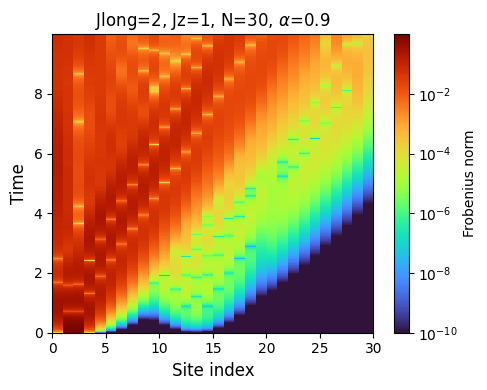

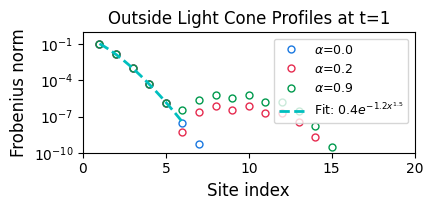

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = [0, 2, 9]
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
all_max = 0
for J in Jlong_values:
    data = load_mathematica_data(os.path.join(base_path, f"N30B0LFIMb2lcfarVaryalpha{J}.txt"))
    all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"N30B0LFIMb2lcfarVaryalpha{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 4))
    im = plt.imshow(
    np.clip(raw_data, 1e-10, None),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    norm=mcolors.LogNorm(vmin=1e-10, vmax=all_max),
    interpolation="nearest",   # 👈 No smoothing
    extent=[0, raw_data.shape[1], t_min, t_max],
    rasterized=True            # 👈 Forces raster pixels in SVG/PDF
    )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    plt.title(fr"Jlong=2, Jz=1, N=30, $\alpha$={J/10:.1f}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N{J}.svg", dpi=600)
    plt.show()

# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(4.5, 2.2))
# High-contrast RGB colors (normalized to [0,1])
colors = [
    (0.10, 0.47, 0.88),  # bright blue
    (0.90, 0.17, 0.31),  # red/pink
    (0.00, 0.60, 0.30),  # teal-green
    (0.12, 0.45, 0.23)   # darker green
]


all_x_fit = []
all_y_fit = []

for J, c in zip(Jlong_values, colors):
    file_path = os.path.join(base_path, f"N30B0LFIMb2lcfarVaryalpha{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 4:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect first few points for a single global fit
    n_fit = 6
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    plt.semilogy(
    sites, profile, "o",
    markerfacecolor='none',     # open circles (no fill)
    markeredgecolor=c,          # colored edges
    markersize=5,
    label=fr"$\alpha$={J/10:.1f}"
    )   


# -----------------------------
# Fit single model to combined early points
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Compute global fit curve
x_dense = np.linspace(1, max(x_fit_points), 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)

# Add the single global fit to the same plot
plt.semilogy(x_dense, y_dense, "c--", linewidth=2,
             label=fr"Fit: ${A_fit:.1f}e^{{-{a_fit:.1f}x^{{{p_fit:.1f}}}}}$")

# Final formatting
plt.ylim(1e-10, 1)
plt.xlim(0, 20)
plt.xlabel("Site index", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plt/Profiles_Varyalpha.svg", dpi=600)
plt.show()


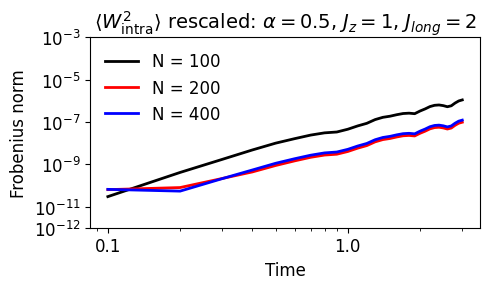

t = 0.10 → slope = 1.094
t = 0.50 → slope = -3.508
t = 2.00 → slope = -3.497


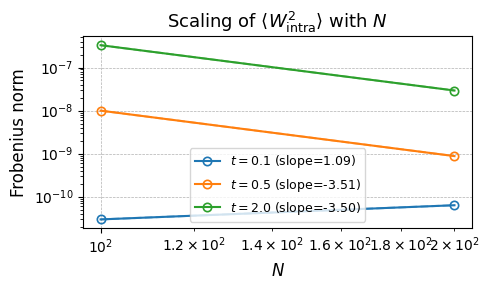

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Example: put your lists here (from Mathematica output)
sitesum100 = np.array([
    [0.1, 2.95795e-11], [0.2, 4.11164e-10], [0.3, 1.71338e-9],
    [0.4, 4.75062e-9], [0.5, 9.95777e-9], [0.6, 1.62452e-8],
    [0.7, 2.40116e-8], [0.8, 3.06272e-8], [0.9, 3.36132e-8],
    [1.0, 4.54229e-8], [1.1, 6.53094e-8], [1.2, 8.64266e-8],
    [1.3, 1.29877e-7], [1.4, 1.66198e-7], [1.5, 1.87698e-7],
    [1.6, 2.21240e-7], [1.7, 2.51343e-7], [1.8, 2.61102e-7],
    [1.9, 2.46807e-7], [2.0, 3.30038e-7], [2.1, 4.14858e-7],
    [2.2, 5.35527e-7], [2.3, 6.15428e-7], [2.4, 6.37870e-7],
    [2.5, 5.93794e-7], [2.6, 5.26324e-7], [2.7, 5.83286e-7],
    [2.8, 7.87361e-7], [2.9, 9.88648e-7], [3.0, 1.10528e-6]
])

sitesum200 = np.array([
    [0.1, 6.31498e-11], [0.2, 7.93421e-11], [0.3, 2.13737e-10],
    [0.4, 4.34403e-10], [0.5, 8.75189e-10], [0.6, 1.44740e-9],
    [0.7, 2.13933e-9], [0.8, 2.73084e-9], [0.9, 2.99738e-9],
    [1.0, 4.02700e-9], [1.1, 5.79881e-9], [1.2, 7.66038e-9],
    [1.3, 1.15110e-8], [1.4, 1.47227e-8], [1.5, 1.66077e-8],
    [1.6, 1.96149e-8], [1.7, 2.22808e-8], [1.8, 2.31438e-8],
    [1.9, 2.18970e-8], [2.0, 2.92229e-8], [2.1, 3.67442e-8],
    [2.2, 4.73733e-8], [2.3, 5.44056e-8], [2.4, 5.63562e-8],
    [2.5, 5.24498e-8], [2.6, 4.64868e-8], [2.7, 5.18199e-8],
    [2.8, 6.98086e-8], [2.9, 8.74469e-8], [3.0, 9.75777e-8]
])

sitesum400 = np.array([
    [0.1, 6.51926e-11], [0.2, 5.37986e-11], [0.3, 2.10346e-10],
    [0.4, 5.36232e-10], [0.5, 1.11159e-9], [0.6, 1.82618e-9],
    [0.7, 2.68316e-9], [0.8, 3.44915e-9], [0.9, 3.79734e-9],
    [1.0, 5.08680e-9], [1.1, 7.31319e-9], [1.2, 9.64373e-9],
    [1.3, 1.44840e-8], [1.4, 1.85285e-8], [1.5, 2.09310e-8],
    [1.6, 2.46757e-8], [1.7, 2.80252e-8], [1.8, 2.91146e-8],
    [1.9, 2.75248e-8], [2.0, 3.68117e-8], [2.1, 4.62894e-8],
    [2.2, 5.96937e-8], [2.3, 6.85384e-8], [2.4, 7.09884e-8],
    [2.5, 6.60122e-8], [2.6, 5.85044e-8], [2.7, 6.50064e-8],
    [2.8, 8.76549e-8], [2.9, 1.09862e-7], [3.0, 1.22571e-7]
])

# --- Rescale like in Mathematica ---
sitesum100Rescaled = np.column_stack([sitesum100[:,0], sitesum100[:,1]])
sitesum200Rescaled = np.column_stack([sitesum200[:,0], sitesum200[:,1]])
sitesum400Rescaled = np.column_stack([sitesum400[:,0], sitesum400[:,1]])


# --- Plot ---
plt.figure(figsize=(5,3))

plt.plot(sitesum100Rescaled[:,0], sitesum100Rescaled[:,1], 'k-', lw=2, label="N = 100")
plt.plot(sitesum200Rescaled[:,0], sitesum200Rescaled[:,1], 'r-', lw=2, label="N = 200")
plt.plot(sitesum400Rescaled[:,0], sitesum400Rescaled[:,1], 'b-', lw=2, label="N = 400")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Time", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(r"$\langle W_{\mathrm{intra}}^2 \rangle$ rescaled: $\alpha=0.5$, $J_z=1$, $J_{long}=2$",
          fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=12)  # tick label size
plt.legend(loc="upper left", frameon=False, fontsize=12)

# plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.ylim(1e-12, 1e-3)

# Fix log x-axis ticks to show raw numbers
ax = plt.gca()
ax.set_xscale("log")

# Major ticks at 0.1, 1, 10 ...
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1.0], numticks=20))
# Minor ticks for 2–9 between decades
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Force raw number formatting instead of 10^n
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
# ax.xaxis.set_minor_formatter(ticker.NullFormatter())  # hide minor tick labels if too crowded

ax.set_yscale("log")

# Manually set ticks at alternate powers of 10
ax.set_yticks([1e-12,1e-11, 1e-9, 1e-7, 1e-5, 1e-3])

plt.tight_layout()

# === Save ===
# plt.savefig("plt/ScalingWithN_a05.svg", dpi=600, bbox_inches="tight")

plt.show()

datasets = {100: sitesum100, 200: sitesum200}#, 400: sitesum400}
times_to_check = [0.1, 0.5, 2.0]
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(5,3))

for t_fixed, c in zip(times_to_check, colors):
    values_at_t = []
    Ns = []

    for N, data in datasets.items():
        t = data[:, 0]
        y = data[:, 1]
        idx = np.argmin(np.abs(t - t_fixed))
        val = y[idx]
        values_at_t.append(val)
        Ns.append(N)

    Ns = np.array(Ns)
    values_at_t = np.array(values_at_t)

    # --- Log–log fit (y = A * N^slope) ---
    mask = (values_at_t > 0)
    slope, intercept = np.polyfit(np.log(Ns[mask]), np.log(values_at_t[mask]), 1)
    print(f"t = {t_fixed:>4.2f} → slope = {slope:.3f}")

    y_fit = np.exp(intercept) * Ns ** slope

    plt.loglog(Ns, values_at_t, "o-", color=c, markerfacecolor='none',
               markeredgewidth=1.2, label=fr"$t={t_fixed}$ (slope={slope:.2f})")
    plt.loglog(Ns, y_fit, "--", color=c, alpha=0.5)



plt.xlabel(r"$N$", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(r"Scaling of $\langle W_{\mathrm{intra}}^2 \rangle$ with $N$", fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, which="major", ls="--", lw=0.5)
plt.tight_layout()
# plt.savefig("plt/Scaling_vs_N_fixed_t.svg", dpi=600)
plt.show()

